# 13B — Final 3-Seed Replication: Decoupled Box-Supervised Localization Adapter — Seeds 123 & 2026

**Project:** Pediatric Chest X-ray / final robustness stage  
**Controller ID:** `F02_LocalizationAdapter_3Seed_Replication`  
**Frozen reference localization run:** `M08_DecoupledLocalizationAdapter_Seed42`  
**New adapter runs:** seeds **123** and **2026**  
**Base classifiers:** the matching seed-specific multitask checkpoints from 13A / F01  
**Platform:** Kaggle  
**Target GPU:** NVIDIA T4  

## Why this experiment comes now

13A completed the paper-quality 3-seed replication of the disease + finding multitask classifier.

13B now repeats the successful **10E decoupled localization strategy** for the same additional seeds:

```text
Seed 42:   09A-42   → M08 localization adapter      (already completed)
Seed 123:  F01-123  → F02 localization adapter      (this notebook)
Seed 2026: F01-2026 → F02 localization adapter      (this notebook)
```

The purpose is to determine whether the strong box-guided localization result is stable across random seeds while the disease classifier remains mathematically untouched.

---

## Exact 10E protocol being replicated

Only the random seed and corresponding base classifier checkpoint change.

Frozen 10E settings:

- ResNet50 spatial feature map from the matching multitask classifier
- **base classifier fully frozen**
- base feature maps **detached**
- localization adapter:
  - `Conv1x1(2048 → 256)`
  - `GroupNorm(32)`
  - `ReLU`
  - `Conv1x1(256 → 37)`
- local finding loss: Binary Focal Loss, `gamma = 2`
- local finding loss weight: `1.0`
- box loss: negative log attention mass inside the radiologist union box
- box loss weight: `0.10`
- AdamW
- adapter LR: `1e-4`
- weight decay: `1e-4`
- 320 × 320 images
- 80 × 80 box masks
- max epochs: 15
- early stopping patience: 4
- checkpoint selection: validation **pair-weighted attention mass inside boxes**
- no CGAM fusion
- no calibration
- no official test

The historical normalization used by the executed Stage-09/10 pipeline is preserved exactly for controlled replication.

---

## Main outputs

For each new seed:

- frozen-base disease Macro-AUPRC before and after adapter training;
- max disease-probability difference;
- direct-CAM localization baseline;
- adapter attention mass inside boxes;
- adapter pointing-game accuracy;
- adapter finding Macro-AUPRC;
- per-finding localization;
- best adapter checkpoint.

Then the notebook combines seeds **42, 123, 2026** and reports:

- mean ± SD of attention mass;
- mean ± SD of pointing-game accuracy;
- mean ± SD of adapter finding Macro-AUPRC;
- direct-CAM vs adapter localization gains;
- per-finding 3-seed localization mean ± SD.

The official test remains sealed.


In [1]:
# ============================================================
# 1. Install DICOM decoders
# ============================================================
%pip install -q -U "pylibjpeg[all]" pyjpegls

print("✅ DICOM decoder packages ready.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 90.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 272.3/272.3 kB 18.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
✅ DICOM decoder packages ready.


In [2]:
# ============================================================
# 2. Imports + frozen controller configuration
# ============================================================
import os
import sys
import gc
import io
import json
import time
import math
import random
import hashlib
import zipfile
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pydicom
from pydicom.pixels import apply_modality_lut, apply_voi_lut
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms
from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode
from torchvision.models import resnet50

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    f1_score,
    recall_score,
    confusion_matrix,
)

from tqdm.auto import tqdm

CONTROLLER_ID = "F02_LocalizationAdapter_3Seed_Replication"

REFERENCE_LOCALIZATION_EXPERIMENT_ID = (
    "M08_DecoupledLocalizationAdapter_Seed42"
)

REFERENCE_BASE_EXPERIMENT_ID = (
    "M01_DiseaseFinding_Multitask_Seed42"
)

F01_CONTROLLER_ID = (
    "F01_Multitask_3Seed_Replication"
)

BASE_EXPERIMENT_IDS = {
    123:
        "F01_Multitask_Seed123",
    2026:
        "F01_Multitask_Seed2026",
}

RUN_EXPERIMENT_IDS = {
    123:
        "F02_LocalizationAdapter_Seed123",
    2026:
        "F02_LocalizationAdapter_Seed2026",
}

NEW_SEEDS = [
    123,
    2026,
]

IMAGE_SIZE = 320
BOX_MASK_SIZE = 80

BATCH_SIZE = 8
NUM_WORKERS = 4

MAX_EPOCHS = 15
EARLY_STOPPING_PATIENCE = 4

LOCALIZATION_LR = 1e-4
LOCALIZATION_WEIGHT_DECAY = 1e-4

FOCAL_GAMMA = 2.0
LOCAL_FINDING_LOSS_WEIGHT = 1.0
BOX_LOSS_WEIGHT = 0.10

FIXED_THRESHOLD = 0.5
USE_AMP = True

BASE_REPRO_TOLERANCE = 5e-4

EXPECTED_SPLIT_MANIFEST_SHA256 = (
    "3d2f8de854c9f61382b1ef5594264af739fcb1d3d9ca8ca9fe8d388380363770"
)

OUTPUT_ROOT = Path(
    f"/kaggle/working/PediCGAM/{CONTROLLER_ID}"
)

SUMMARY_DIR = (
    OUTPUT_ROOT
    / "summary"
)

CACHE_DIR = Path(
    f"/kaggle/working/PediCGAM_cache/{CONTROLLER_ID}_{IMAGE_SIZE}"
)

EXTRACT_DIR = Path(
    "/kaggle/working/13b_extracted"
)

for d in [
    OUTPUT_ROOT,
    SUMMARY_DIR,
    CACHE_DIR,
    EXTRACT_DIR,
]:
    d.mkdir(
        parents=True,
        exist_ok=True,
    )


def seed_everything(
    seed,
):
    random.seed(
        seed
    )
    np.random.seed(
        seed
    )
    torch.manual_seed(
        seed
    )
    torch.cuda.manual_seed_all(
        seed
    )
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

if (
    DEVICE.type
    != "cuda"
):
    raise RuntimeError(
        "GPU is not active. Enable a Kaggle GPU accelerator."
    )

print(
    "Notebook build:",
    "13B_LOCALIZATION_FINAL_REPLICATION_V1",
)
print(
    "Controller:",
    CONTROLLER_ID,
)
print(
    "New seeds:",
    NEW_SEEDS,
)
print(
    "Device:",
    DEVICE,
)
print(
    "GPU:",
    torch.cuda.get_device_name(
        0
    ),
)


Notebook build: 13B_LOCALIZATION_FINAL_REPLICATION_V1
Controller: F02_LocalizationAdapter_3Seed_Replication
New seeds: [123, 2026]
Device: cuda
GPU: Tesla T4


# 3. Required Kaggle inputs

Attach **four inputs**:

1. **VinDr-PCXR**
2. **Stage-02 frozen split output**
3. **13A / F01 output** containing:
   - `F01_Multitask_Seed123/best_model.pth`
   - `F01_Multitask_Seed2026/best_model.pth`
4. **10E / M08 seed-42 output** containing:
   - `best_localization_adapter.pth`
   - `config.json`
   - `09A_vs_10E_comparison.csv`
   - `localization_adapter_summary.csv`
   - `localization_adapter_per_finding.csv`

No 09A seed-42 input is required because seed 42 is used only as the already-completed reference row.

Calibration and official test remain unused.


In [3]:
# ============================================================
# 4. Locate VinDr-PCXR
# ============================================================
KAGGLE_INPUT = Path(
    "/kaggle/input"
)


def find_vindr_root(
    search_root=KAGGLE_INPUT,
):
    candidates = []

    for f in search_root.rglob(
        "image_labels_train.csv"
    ):
        folder = f.parent

        names = {
            p.name
            for p in folder.iterdir()
            if p.is_file()
        }

        score = sum(
            name in names
            for name in [
                "image_labels_train.csv",
                "annotations_train.csv",
            ]
        )

        candidates.append(
            (
                score,
                folder,
            )
        )

    candidates.sort(
        key=lambda x: (
            -x[
                0
            ],
            len(
                str(
                    x[
                        1
                    ]
                )
            ),
        )
    )

    return candidates


vindr_candidates = (
    find_vindr_root()
)

if (
    not vindr_candidates
):
    raise FileNotFoundError(
        "VinDr-PCXR was not found."
    )

DATA_ROOT = (
    vindr_candidates[
        0
    ][
        1
    ]
)

TRAIN_DICOM_DIR = (
    DATA_ROOT
    / "train"
)

if (
    not TRAIN_DICOM_DIR.exists()
):
    raise FileNotFoundError(
        "VinDr-PCXR training DICOM folder was not found."
    )

print(
    "VinDr-PCXR root:",
    DATA_ROOT,
)


VinDr-PCXR root: /kaggle/input/datasets/kalloldaskushol/vindr-pcxr/Pediatric Chest X-ray/physionet.org/files/vindr-pcxr/1.0.0


In [4]:
# ============================================================
# 5. Locate + verify frozen Stage-02 split
# ============================================================
def sha256_file(
    path,
):
    h = hashlib.sha256()

    with open(
        path,
        "rb",
    ) as f:
        for block in iter(
            lambda:
                f.read(
                    1024
                    * 1024
                ),
            b"",
        ):
            h.update(
                block
            )

    return h.hexdigest()


def find_frozen_manifest():
    for p in KAGGLE_INPUT.rglob(
        "fixed_split_manifest.csv"
    ):
        if (
            sha256_file(
                p
            )
            == EXPECTED_SPLIT_MANIFEST_SHA256
        ):
            return (
                p,
                "direct_csv",
            )

    for zip_path in KAGGLE_INPUT.rglob(
        "*.zip"
    ):
        try:
            with zipfile.ZipFile(
                zip_path,
                "r",
            ) as zf:
                members = [
                    n
                    for n in zf.namelist()
                    if n.endswith(
                        "fixed_split_manifest.csv"
                    )
                ]

                for member in members:
                    raw = zf.read(
                        member
                    )

                    if (
                        hashlib.sha256(
                            raw
                        ).hexdigest()
                        == EXPECTED_SPLIT_MANIFEST_SHA256
                    ):
                        target = (
                            EXTRACT_DIR
                            / "fixed_split_manifest.csv"
                        )

                        target.write_bytes(
                            raw
                        )

                        return (
                            target,
                            f"zip:{zip_path.name}",
                        )

        except zipfile.BadZipFile:
            pass

    return (
        None,
        None,
    )


MANIFEST_PATH, MANIFEST_SOURCE = (
    find_frozen_manifest()
)

if (
    MANIFEST_PATH
    is None
):
    raise FileNotFoundError(
        "Frozen Stage-02 split was not found."
    )

manifest_hash = sha256_file(
    MANIFEST_PATH
)

if (
    manifest_hash
    != EXPECTED_SPLIT_MANIFEST_SHA256
):
    raise RuntimeError(
        "STOP: frozen split SHA-256 mismatch."
    )

print(
    "Manifest:",
    MANIFEST_PATH,
)
print(
    "Source:",
    MANIFEST_SOURCE,
)
print(
    "SHA-256:",
    manifest_hash,
)
print(
    "✅ Frozen split verified."
)


Manifest: /kaggle/input/notebooks/kalloldaskushol/02-fixed-train-validation-calibration-split/PediCGAM/stage02_fixed_split/splits/fixed_split_manifest.csv
Source: direct_csv
SHA-256: 3d2f8de854c9f61382b1ef5594264af739fcb1d3d9ca8ca9fe8d388380363770
✅ Frozen split verified.


In [5]:
# ============================================================
# 6. Robust artifact readers for F01 + M08
# ============================================================
def extract_zip_member(
    zip_path,
    member,
    target_name,
):
    target = (
        EXTRACT_DIR
        / target_name
    )

    with zipfile.ZipFile(
        zip_path,
        "r",
    ) as zf:
        target.write_bytes(
            zf.read(
                member
            )
        )

    return target


def find_checkpoint_by_experiment_id(
    experiment_id,
):
    for p in KAGGLE_INPUT.rglob(
        "best_model.pth"
    ):
        try:
            ckpt = torch.load(
                p,
                map_location="cpu",
                weights_only=False,
            )

            if (
                ckpt.get(
                    "experiment_id"
                )
                == experiment_id
            ):
                return (
                    p,
                    "direct",
                )
        except Exception:
            pass

    for zip_path in KAGGLE_INPUT.rglob(
        "*.zip"
    ):
        try:
            with zipfile.ZipFile(
                zip_path,
                "r",
            ) as zf:
                members = [
                    n
                    for n in zf.namelist()
                    if n.endswith(
                        "/best_model.pth"
                    )
                    or n
                    == "best_model.pth"
                ]

                for member in members:
                    raw = zf.read(
                        member
                    )

                    target = (
                        EXTRACT_DIR
                        / (
                            experiment_id
                            + "_best_model.pth"
                        )
                    )

                    target.write_bytes(
                        raw
                    )

                    try:
                        ckpt = torch.load(
                            target,
                            map_location="cpu",
                            weights_only=False,
                        )

                        if (
                            ckpt.get(
                                "experiment_id"
                            )
                            == experiment_id
                        ):
                            return (
                                target,
                                f"zip:{zip_path.name}",
                            )

                    except Exception:
                        pass

        except zipfile.BadZipFile:
            pass

    return (
        None,
        None,
    )


BASE_CHECKPOINTS = {}

for seed in NEW_SEEDS:
    expected_id = (
        BASE_EXPERIMENT_IDS[
            seed
        ]
    )

    path, source = (
        find_checkpoint_by_experiment_id(
            expected_id
        )
    )

    if (
        path
        is None
    ):
        raise FileNotFoundError(
            "Could not find F01 base checkpoint: "
            + expected_id
        )

    ckpt = torch.load(
        path,
        map_location="cpu",
        weights_only=False,
    )

    if (
        ckpt.get(
            "split_manifest_sha256"
        )
        != EXPECTED_SPLIT_MANIFEST_SHA256
    ):
        raise RuntimeError(
            f"STOP: seed {seed} base checkpoint split hash mismatch."
        )

    if (
        int(
            ckpt.get(
                "random_seed"
            )
        )
        != seed
    ):
        raise RuntimeError(
            f"STOP: seed {seed} base checkpoint random_seed mismatch."
        )

    if (
        not np.isclose(
            float(
                ckpt.get(
                    "finding_loss_weight"
                )
            ),
            0.5,
        )
    ):
        raise RuntimeError(
            f"STOP: seed {seed} base checkpoint finding weight is not 0.5."
        )

    if (
        ckpt.get(
            "boxes_used"
        )
        is not False
    ):
        raise RuntimeError(
            f"STOP: seed {seed} base checkpoint unexpectedly used boxes."
        )

    BASE_CHECKPOINTS[
        seed
    ] = {
        "path":
            path,
        "source":
            source,
        "checkpoint":
            ckpt,
    }

    print(
        f"✅ Seed {seed} base checkpoint verified:",
        source,
    )


✅ Seed 123 base checkpoint verified: direct
✅ Seed 2026 base checkpoint verified: direct


In [6]:
# ============================================================
# 7. Locate + verify seed-42 M08 reference output
# ============================================================
# Multiple attached notebook outputs can contain generic filenames
# such as config.json. First identify the M08 container by reading
# experiment_id, then load all other M08 files from that SAME container.

M08_DIRECT_ROOT = None
M08_ZIP_PATH = None
M08_CONFIG_PATH = None
M08_CONFIG_SOURCE = None

# 7A. Search direct config.json files and verify experiment_id.
for p in KAGGLE_INPUT.rglob(
    "config.json"
):
    try:
        with open(
            p,
            "r",
        ) as f:
            candidate = json.load(
                f
            )

        if (
            candidate.get(
                "experiment_id"
            )
            == REFERENCE_LOCALIZATION_EXPERIMENT_ID
        ):
            M08_CONFIG_PATH = p
            M08_DIRECT_ROOT = p.parent
            M08_CONFIG_SOURCE = "direct"
            break

    except Exception:
        pass


# 7B. If needed, search inside ZIPs and verify experiment_id.
if (
    M08_CONFIG_PATH
    is None
):
    for zip_path in KAGGLE_INPUT.rglob(
        "*.zip"
    ):
        try:
            with zipfile.ZipFile(
                zip_path,
                "r",
            ) as zf:
                config_members = [
                    n
                    for n in zf.namelist()
                    if n.endswith(
                        "/config.json"
                    )
                    or n
                    == "config.json"
                ]

                for member in config_members:
                    try:
                        candidate = json.loads(
                            zf.read(
                                member
                            ).decode(
                                "utf-8"
                            )
                        )

                        if (
                            candidate.get(
                                "experiment_id"
                            )
                            == REFERENCE_LOCALIZATION_EXPERIMENT_ID
                        ):
                            target = (
                                EXTRACT_DIR
                                / "M08_config.json"
                            )

                            target.write_bytes(
                                zf.read(
                                    member
                                )
                            )

                            M08_CONFIG_PATH = target
                            M08_ZIP_PATH = zip_path
                            M08_CONFIG_SOURCE = (
                                f"zip:{zip_path.name}"
                            )
                            break

                    except Exception:
                        pass

                if (
                    M08_CONFIG_PATH
                    is not None
                ):
                    break

        except zipfile.BadZipFile:
            pass


if (
    M08_CONFIG_PATH
    is None
):
    raise FileNotFoundError(
        "Verified M08 seed-42 config.json was not found."
    )


with open(
    M08_CONFIG_PATH,
    "r",
) as f:
    m08_config = json.load(
        f
    )


def locate_m08_companion(
    filename,
    required=True,
):
    # Direct output: search only beneath the verified M08 output root.
    if (
        M08_DIRECT_ROOT
        is not None
    ):
        matches = list(
            M08_DIRECT_ROOT.rglob(
                filename
            )
        )

        if (
            matches
        ):
            return (
                matches[
                    0
                ],
                "direct",
            )

    # ZIP output: search only inside the verified M08 ZIP.
    if (
        M08_ZIP_PATH
        is not None
    ):
        with zipfile.ZipFile(
            M08_ZIP_PATH,
            "r",
        ) as zf:
            members = [
                n
                for n in zf.namelist()
                if n.endswith(
                    "/"
                    + filename
                )
                or n
                == filename
            ]

            if (
                members
            ):
                target = (
                    EXTRACT_DIR
                    / (
                        "M08_"
                        + filename
                    )
                )

                target.write_bytes(
                    zf.read(
                        members[
                            0
                        ]
                    )
                )

                return (
                    target,
                    f"zip:{M08_ZIP_PATH.name}",
                )

    if (
        required
    ):
        raise FileNotFoundError(
            "Missing M08 companion artifact: "
            + filename
        )

    return (
        None,
        None,
    )


M08_FILES = {
    "config.json": {
        "path":
            M08_CONFIG_PATH,
        "source":
            M08_CONFIG_SOURCE,
    },
}

for filename in [
    "09A_vs_10E_comparison.csv",
    "localization_adapter_summary.csv",
    "localization_adapter_per_finding.csv",
    "environment_info.json",
]:
    path, source = (
        locate_m08_companion(
            filename,
            required=True,
        )
    )

    M08_FILES[
        filename
    ] = {
        "path":
            path,
        "source":
            source,
    }


if (
    m08_config.get(
        "base_experiment_id"
    )
    != REFERENCE_BASE_EXPERIMENT_ID
):
    raise RuntimeError(
        "STOP: M08 reference is not tied to 09A seed42."
    )

if (
    int(
        m08_config.get(
            "seed"
        )
    )
    != 42
):
    raise RuntimeError(
        "STOP: M08 reference is not seed 42."
    )

if (
    m08_config.get(
        "split_manifest_sha256"
    )
    != EXPECTED_SPLIT_MANIFEST_SHA256
):
    raise RuntimeError(
        "STOP: M08 reference split hash mismatch."
    )

for key, expected in [
    (
        "localization_learning_rate",
        LOCALIZATION_LR,
    ),
    (
        "localization_weight_decay",
        LOCALIZATION_WEIGHT_DECAY,
    ),
    (
        "local_finding_loss_weight",
        LOCAL_FINDING_LOSS_WEIGHT,
    ),
    (
        "box_loss_weight",
        BOX_LOSS_WEIGHT,
    ),
]:
    if (
        not np.isclose(
            float(
                m08_config.get(
                    key
                )
            ),
            float(
                expected
            ),
        )
    ):
        raise RuntimeError(
            f"STOP: M08 reference protocol mismatch for {key}."
        )

if (
    int(
        m08_config.get(
            "image_size"
        )
    )
    != IMAGE_SIZE
):
    raise RuntimeError(
        "STOP: M08 image size does not match."
    )

if (
    int(
        m08_config.get(
            "box_mask_size"
        )
    )
    != BOX_MASK_SIZE
):
    raise RuntimeError(
        "STOP: M08 box-mask size does not match."
    )

print(
    "✅ M08 seed-42 reference protocol verified."
)
print(
    "M08 source:",
    M08_CONFIG_SOURCE,
)


✅ M08 seed-42 reference protocol verified.
M08 source: direct


In [7]:
# ============================================================
# 8. Load labels + frozen train/validation split
# ============================================================
labels = pd.read_csv(
    DATA_ROOT
    / "image_labels_train.csv"
)

manifest = pd.read_csv(
    MANIFEST_PATH
)

NON_LABEL_COLUMNS = [
    "image_id",
    "rad_ID",
]

LABEL_COLUMNS = [
    c
    for c in labels.columns
    if c
    not in NON_LABEL_COLUMNS
]

if (
    len(
        LABEL_COLUMNS
    )
    != 15
):
    raise RuntimeError(
        "Expected 15 disease outputs."
    )

if (
    "No finding"
    not in LABEL_COLUMNS
):
    raise RuntimeError(
        "Disease label No finding is missing."
    )

PATHOLOGY_COLUMNS = [
    c
    for c in LABEL_COLUMNS
    if c
    != "No finding"
]

df = manifest.merge(
    labels,
    on="image_id",
    how="left",
    validate="one_to_one",
)

if (
    df[
        LABEL_COLUMNS
    ]
    .isna()
    .any()
    .any()
):
    raise RuntimeError(
        "Split manifest contains missing disease labels."
    )

split_counts = (
    df[
        "split"
    ].value_counts()
)

if (
    int(
        split_counts[
            "train"
        ]
    )
    != 5408
    or int(
        split_counts[
            "validation"
        ]
    )
    != 1159
    or int(
        split_counts[
            "calibration"
        ]
    )
    != 1161
):
    raise RuntimeError(
        "Frozen split counts are incorrect."
    )

train_df = (
    df[
        df[
            "split"
        ]
        == "train"
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

val_df = (
    df[
        df[
            "split"
        ]
        == "validation"
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

print(
    "Train:",
    len(
        train_df
    ),
)
print(
    "Validation:",
    len(
        val_df
    ),
)
print(
    "Calibration present but unused:",
    int(
        split_counts[
            "calibration"
        ]
    ),
)


Train: 5408
Validation: 1159
Calibration present but unused: 1161


In [8]:
# ============================================================
# 9. Build 37 finding targets from annotation class_name
# ============================================================
annotations = pd.read_csv(
    DATA_ROOT
    / "annotations_train.csv"
)

required_annotation_columns = {
    "image_id",
    "class_name",
    "x_min",
    "y_min",
    "x_max",
    "y_max",
}

missing_cols = (
    required_annotation_columns
    - set(
        annotations.columns
    )
)

if (
    missing_cols
):
    raise RuntimeError(
        "annotations_train.csv is missing: "
        + str(
            sorted(
                missing_cols
            )
        )
    )

annotation_class_names = (
    annotations[
        "class_name"
    ]
    .dropna()
    .astype(
        str
    )
    .unique()
    .tolist()
)

FINDING_CLASSES = (
    [
        "No finding"
    ]
    + sorted(
        x
        for x in annotation_class_names
        if x
        != "No finding"
    )
)

if (
    len(
        FINDING_CLASSES
    )
    != 37
):
    raise RuntimeError(
        "Expected 37 finding outputs."
    )

NO_FINDING_INDEX = (
    FINDING_CLASSES.index(
        "No finding"
    )
)

FINDING_TARGET_COLUMNS = [
    f"finding_target_{i:02d}"
    for i in range(
        len(
            FINDING_CLASSES
        )
    )
]

finding_matrix = pd.crosstab(
    annotations[
        "image_id"
    ].astype(
        str
    ),
    annotations[
        "class_name"
    ].astype(
        str
    ),
)

finding_matrix = (
    finding_matrix
    .reindex(
        columns=
            FINDING_CLASSES,
        fill_value=0,
    )
    .clip(
        upper=1
    )
    .astype(
        np.float32
    )
)

df[
    "image_id_str"
] = (
    df[
        "image_id"
    ].astype(
        str
    )
)

for target_col, class_name in zip(
    FINDING_TARGET_COLUMNS,
    FINDING_CLASSES,
):
    df[
        target_col
    ] = (
        df[
            "image_id_str"
        ]
        .map(
            finding_matrix[
                class_name
            ]
        )
        .fillna(
            0
        )
        .astype(
            np.float32
        )
    )

train_df = (
    df[
        df[
            "split"
        ]
        == "train"
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

val_df = (
    df[
        df[
            "split"
        ]
        == "validation"
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

finding_class_map = pd.DataFrame({
    "finding_index":
        range(
            len(
                FINDING_CLASSES
            )
        ),
    "class_name":
        FINDING_CLASSES,
})

finding_class_map.to_csv(
    SUMMARY_DIR
    / "finding_class_map.csv",
    index=False,
)

print(
    "Finding outputs:",
    len(
        FINDING_CLASSES
    ),
)
print(
    "Actual local findings:",
    len(
        FINDING_CLASSES
    )
    - 1,
)
print(
    "Numeric class_id used: NO"
)


Finding outputs: 37
Actual local findings: 36
Numeric class_id used: NO


In [9]:
# ============================================================
# 10. DICOM index
# ============================================================
dicom_paths = {
    p.stem:
        p
    for p in TRAIN_DICOM_DIR.rglob(
        "*"
    )
    if (
        p.is_file()
        and p.suffix.lower()
        in {
            ".dicom",
            ".dcm",
        }
    )
}

required_ids = (
    set(
        train_df[
            "image_id"
        ].astype(
            str
        )
    )
    | set(
        val_df[
            "image_id"
        ].astype(
            str
        )
    )
)

missing_files = (
    required_ids
    - set(
        dicom_paths.keys()
    )
)

if (
    missing_files
):
    raise FileNotFoundError(
        "Some frozen train/validation DICOM files are missing."
    )

print(
    "DICOM files indexed:",
    len(
        dicom_paths
    ),
)
print(
    "Train+validation IDs:",
    len(
        required_ids
    ),
)
print(
    "✅ DICOM index complete."
)


DICOM files indexed: 7728
Train+validation IDs: 6567
✅ DICOM index complete.


In [10]:
# ============================================================
# 11. Prepare normalized valid bounding boxes
# ============================================================
BOX_COLS = [
    "x_min",
    "y_min",
    "x_max",
    "y_max",
]

box_numeric = (
    annotations[
        BOX_COLS
    ]
    .apply(
        pd.to_numeric,
        errors="coerce",
    )
)

valid_box_flag = (
    box_numeric.notna()
    .all(
        axis=1
    )
    & (
        box_numeric[
            "x_max"
        ]
        > box_numeric[
            "x_min"
        ]
    )
    & (
        box_numeric[
            "y_max"
        ]
        > box_numeric[
            "y_min"
        ]
    )
    & (
        box_numeric[
            BOX_COLS
        ]
        >= 0
    ).all(
        axis=1
    )
)

valid_boxes = (
    annotations.loc[
        valid_box_flag
    ]
    .copy()
)

for c in BOX_COLS:
    valid_boxes[
        c
    ] = (
        box_numeric.loc[
            valid_box_flag,
            c,
        ]
        .astype(
            float
        )
    )

valid_boxes = (
    valid_boxes[
        valid_boxes[
            "class_name"
        ].astype(
            str
        )
        != "No finding"
    ]
    .copy()
)

valid_boxes[
    "image_id"
] = (
    valid_boxes[
        "image_id"
    ].astype(
        str
    )
)

valid_boxes = (
    valid_boxes[
        valid_boxes[
            "image_id"
        ].isin(
            required_ids
        )
    ]
    .copy()
)

boxed_ids = sorted(
    valid_boxes[
        "image_id"
    ]
    .unique()
    .tolist()
)

dimension_rows = []

for image_id in tqdm(
    boxed_ids,
    desc=
        "Reading boxed-image dimensions",
):
    ds = pydicom.dcmread(
        str(
            dicom_paths[
                image_id
            ]
        ),
        stop_before_pixels=True,
        specific_tags=[
            "Rows",
            "Columns",
        ],
    )

    dimension_rows.append({
        "image_id":
            image_id,
        "rows":
            int(
                ds.Rows
            ),
        "columns":
            int(
                ds.Columns
            ),
    })

dimensions_df = pd.DataFrame(
    dimension_rows
)

valid_boxes = valid_boxes.merge(
    dimensions_df,
    on="image_id",
    how="left",
    validate="many_to_one",
)

valid_boxes[
    "nx_min"
] = (
    valid_boxes[
        "x_min"
    ]
    / valid_boxes[
        "columns"
    ]
).clip(
    0,
    1,
)

valid_boxes[
    "nx_max"
] = (
    valid_boxes[
        "x_max"
    ]
    / valid_boxes[
        "columns"
    ]
).clip(
    0,
    1,
)

valid_boxes[
    "ny_min"
] = (
    valid_boxes[
        "y_min"
    ]
    / valid_boxes[
        "rows"
    ]
).clip(
    0,
    1,
)

valid_boxes[
    "ny_max"
] = (
    valid_boxes[
        "y_max"
    ]
    / valid_boxes[
        "rows"
    ]
).clip(
    0,
    1,
)

post_clip_valid = (
    (
        valid_boxes[
            "nx_max"
        ]
        > valid_boxes[
            "nx_min"
        ]
    )
    & (
        valid_boxes[
            "ny_max"
        ]
        > valid_boxes[
            "ny_min"
        ]
    )
)

if (
    not post_clip_valid.all()
):
    raise RuntimeError(
        "At least one box became invalid after normalization."
    )

finding_to_index = {
    name:
        i
    for i, name in enumerate(
        FINDING_CLASSES
    )
}

BOXES_BY_IMAGE = {}

for image_id, group in valid_boxes.groupby(
    "image_id"
):
    items = []

    for row in group.itertuples(
        index=False
    ):
        items.append(
            (
                finding_to_index[
                    str(
                        row.class_name
                    )
                ],
                float(
                    row.nx_min
                ),
                float(
                    row.ny_min
                ),
                float(
                    row.nx_max
                ),
                float(
                    row.ny_max
                ),
            )
        )

    BOXES_BY_IMAGE[
        str(
            image_id
        )
    ] = items

box_summary = pd.DataFrame([
    {
        "metric":
            "valid_box_rows_train_validation",
        "value":
            int(
                len(
                    valid_boxes
                )
            ),
    },
    {
        "metric":
            "unique_boxed_images_train_validation",
        "value":
            int(
                len(
                    BOXES_BY_IMAGE
                )
            ),
    },
    {
        "metric":
            "boxed_train_images",
        "value":
            int(
                train_df[
                    "image_id"
                ]
                .astype(
                    str
                )
                .isin(
                    BOXES_BY_IMAGE
                )
                .sum()
            ),
    },
    {
        "metric":
            "boxed_validation_images",
        "value":
            int(
                val_df[
                    "image_id"
                ]
                .astype(
                    str
                )
                .isin(
                    BOXES_BY_IMAGE
                )
                .sum()
            ),
    },
])

box_summary.to_csv(
    SUMMARY_DIR
    / "box_annotation_summary.csv",
    index=False,
)

display(
    box_summary
)
print(
    "✅ Box metadata prepared."
)


Reading boxed-image dimensions:   0%|          | 0/2195 [00:00<?, ?it/s]

,metric,value
0,valid_box_rows_train_validation,4433
1,unique_boxed_images_train_validation,2195
2,boxed_train_images,1808
3,boxed_validation_images,387


✅ Box metadata prepared.


In [11]:
# ============================================================
# 12. Frozen pathology Head / Middle / Tail groups
# ============================================================
def load_stage02_csv(
    filename,
):
    matches = list(
        KAGGLE_INPUT.rglob(
            filename
        )
    )

    if (
        matches
    ):
        return pd.read_csv(
            matches[
                0
            ]
        )

    for zip_path in KAGGLE_INPUT.rglob(
        "*.zip"
    ):
        try:
            with zipfile.ZipFile(
                zip_path,
                "r",
            ) as zf:
                members = [
                    n
                    for n in zf.namelist()
                    if n.endswith(
                        filename
                    )
                ]

                if (
                    members
                ):
                    return pd.read_csv(
                        io.BytesIO(
                            zf.read(
                                members[
                                    0
                                ]
                            )
                        )
                    )

        except zipfile.BadZipFile:
            pass

    return None


rarity_groups = (
    load_stage02_csv(
        "frozen_pathology_head_middle_tail_groups.csv"
    )
)

if (
    rarity_groups
    is None
):
    raise FileNotFoundError(
        "Frozen pathology rarity groups were not found."
    )

rarity_groups = (
    rarity_groups[
        [
            "label",
            "positive_images",
            "frequency_rank",
            "rarity_group",
        ]
    ]
    .copy()
)

if (
    set(
        rarity_groups[
            "label"
        ]
    )
    != set(
        PATHOLOGY_COLUMNS
    )
):
    raise RuntimeError(
        "Frozen rarity labels do not match pathology labels."
    )

GROUP_TO_LABELS = {
    group:
        rarity_groups.loc[
            rarity_groups[
                "rarity_group"
            ]
            == group,
            "label",
        ].tolist()
    for group in [
        "Head",
        "Middle",
        "Tail",
    ]
}

display(
    rarity_groups
)


,label,positive_images,frequency_rank,rarity_group
0,Bronchitis,842,1,Head
1,Brocho-pneumonia,545,2,Head
2,Bronchiolitis,497,3,Head
3,Other disease,412,4,Head
4,Pneumonia,392,5,Head
5,Hyaline membrane disease,19,6,Middle
6,Tuberculosis,14,7,Middle
7,Situs inversus,11,8,Middle
8,Mediastinal tumor,8,9,Middle
9,Pleuro-pneumonia,6,10,Middle


In [12]:
# ============================================================
# 13. DICOM preprocessing + shared cache
# ============================================================
def dicom_to_uint8_320(
    path,
    output_size=IMAGE_SIZE,
):
    ds = pydicom.dcmread(
        str(
            path
        )
    )

    arr = ds.pixel_array

    try:
        arr = apply_modality_lut(
            arr,
            ds,
        )
    except Exception:
        arr = np.asarray(
            arr
        )

    try:
        arr = apply_voi_lut(
            arr,
            ds,
        )
    except Exception:
        arr = np.asarray(
            arr
        )

    arr = np.asarray(
        arr,
        dtype=np.float32,
    )

    if (
        not np.isfinite(
            arr
        ).all()
    ):
        finite = arr[
            np.isfinite(
                arr
            )
        ]

        fill = (
            float(
                np.median(
                    finite
                )
            )
            if finite.size
            else 0.0
        )

        arr = np.nan_to_num(
            arr,
            nan=fill,
            posinf=fill,
            neginf=fill,
        )

    if (
        str(
            getattr(
                ds,
                "PhotometricInterpretation",
                "",
            )
        ).upper()
        == "MONOCHROME1"
    ):
        arr = (
            arr.max()
            + arr.min()
            - arr
        )

    lo, hi = np.percentile(
        arr,
        [
            0.5,
            99.5,
        ],
    )

    if (
        not np.isfinite(
            lo
        )
        or not np.isfinite(
            hi
        )
        or hi
        <= lo
    ):
        lo = float(
            arr.min()
        )
        hi = float(
            arr.max()
        )

    if (
        hi
        > lo
    ):
        arr = np.clip(
            arr,
            lo,
            hi,
        )

        arr = (
            arr
            - lo
        ) / (
            hi
            - lo
        )

    else:
        arr = np.zeros_like(
            arr,
            dtype=np.float32,
        )

    arr = (
        arr
        * 255.0
    ).round().astype(
        np.uint8
    )

    image = Image.fromarray(
        arr
    )

    image = image.resize(
        (
            output_size,
            output_size,
        ),
        resample=
            Image.Resampling.BILINEAR,
    )

    return np.asarray(
        image,
        dtype=np.uint8,
    )


def cache_images(
    dataframe,
    split_name,
):
    split_cache = (
        CACHE_DIR
        / split_name
    )

    split_cache.mkdir(
        parents=True,
        exist_ok=True,
    )

    failures = []

    for image_id in tqdm(
        dataframe[
            "image_id"
        ]
        .astype(
            str
        )
        .tolist(),
        desc=
            f"Caching {split_name}",
    ):
        target = (
            split_cache
            / f"{image_id}.npy"
        )

        if (
            target.exists()
        ):
            continue

        try:
            arr = dicom_to_uint8_320(
                dicom_paths[
                    image_id
                ]
            )

            np.save(
                target,
                arr,
                allow_pickle=False,
            )

        except Exception as e:
            failures.append({
                "split":
                    split_name,
                "image_id":
                    image_id,
                "error":
                    (
                        f"{type(e).__name__}: "
                        f"{e}"
                    ),
            })

    return pd.DataFrame(
        failures
    )


cache_failures = pd.concat(
    [
        cache_images(
            train_df,
            "train",
        ),
        cache_images(
            val_df,
            "validation",
        ),
    ],
    ignore_index=True,
)

cache_failures.to_csv(
    SUMMARY_DIR
    / "preprocessing_cache_failures.csv",
    index=False,
)

if (
    len(
        cache_failures
    )
):
    display(
        cache_failures
    )

    raise RuntimeError(
        "Preprocessing failed for at least one image."
    )

print(
    "✅ Train/validation shared cache complete."
)


Caching train:   0%|          | 0/5408 [00:00<?, ?it/s]

Caching validation:   0%|          | 0/1159 [00:00<?, ?it/s]

✅ Train/validation shared cache complete.


# 14. Exact 10E joint image + box-mask transform

Normalization and augmentation are kept identical to the executed 10E seed-42 protocol.

No horizontal or vertical flips are used.


In [13]:
# ============================================================
# 15. Dataset + exact joint transforms
# ============================================================
IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406,
]

# Intentionally preserved from the executed Stage-09/10 pipeline.
IMAGENET_STD = [
    0.229,
    0.320,
    0.225,
]

color_jitter = transforms.ColorJitter(
    brightness=0.10,
    contrast=0.10,
)


def rasterize_box_masks(
    image_id,
):
    masks = torch.zeros(
        (
            len(
                FINDING_CLASSES
            ),
            BOX_MASK_SIZE,
            BOX_MASK_SIZE,
        ),
        dtype=torch.uint8,
    )

    for (
        class_index,
        nx_min,
        ny_min,
        nx_max,
        ny_max,
    ) in BOXES_BY_IMAGE.get(
        str(
            image_id
        ),
        [],
    ):
        x1 = int(
            np.floor(
                nx_min
                * BOX_MASK_SIZE
            )
        )

        y1 = int(
            np.floor(
                ny_min
                * BOX_MASK_SIZE
            )
        )

        x2 = int(
            np.ceil(
                nx_max
                * BOX_MASK_SIZE
            )
        )

        y2 = int(
            np.ceil(
                ny_max
                * BOX_MASK_SIZE
            )
        )

        x1 = int(
            np.clip(
                x1,
                0,
                BOX_MASK_SIZE
                - 1,
            )
        )

        y1 = int(
            np.clip(
                y1,
                0,
                BOX_MASK_SIZE
                - 1,
            )
        )

        x2 = int(
            np.clip(
                x2,
                x1
                + 1,
                BOX_MASK_SIZE,
            )
        )

        y2 = int(
            np.clip(
                y2,
                y1
                + 1,
                BOX_MASK_SIZE,
            )
        )

        masks[
            class_index,
            y1:y2,
            x1:x2,
        ] = 1

    return masks


class JointTrainTransform:
    def __call__(
        self,
        image,
        box_masks,
    ):
        (
            angle,
            translate,
            scale,
            shear,
        ) = transforms.RandomAffine.get_params(
            degrees=[
                -5.0,
                5.0,
            ],
            translate=[
                0.03,
                0.03,
            ],
            scale_ranges=[
                0.95,
                1.05,
            ],
            shears=None,
            img_size=[
                IMAGE_SIZE,
                IMAGE_SIZE,
            ],
        )

        image = TF.affine(
            image,
            angle=angle,
            translate=translate,
            scale=scale,
            shear=shear,
            interpolation=
                InterpolationMode.NEAREST,
            fill=0,
        )

        mask_translate = [
            int(
                round(
                    translate[
                        0
                    ]
                    * BOX_MASK_SIZE
                    / IMAGE_SIZE
                )
            ),
            int(
                round(
                    translate[
                        1
                    ]
                    * BOX_MASK_SIZE
                    / IMAGE_SIZE
                )
            ),
        ]

        box_masks = TF.affine(
            box_masks.float(),
            angle=angle,
            translate=
                mask_translate,
            scale=scale,
            shear=shear,
            interpolation=
                InterpolationMode.NEAREST,
            fill=0,
        )

        box_masks = (
            box_masks
            > 0.5
        ).to(
            torch.uint8
        )

        image = color_jitter(
            image
        )

        image = TF.normalize(
            image,
            mean=
                IMAGENET_MEAN,
            std=
                IMAGENET_STD,
        )

        return (
            image,
            box_masks,
        )


class JointValidationTransform:
    def __call__(
        self,
        image,
        box_masks,
    ):
        image = TF.normalize(
            image,
            mean=
                IMAGENET_MEAN,
            std=
                IMAGENET_STD,
        )

        return (
            image,
            box_masks,
        )


class CachedCXRLocalizationDataset(
    Dataset
):
    def __init__(
        self,
        dataframe,
        split_name,
        cache_root,
        disease_label_columns,
        finding_target_columns,
        transform=None,
    ):
        self.df = (
            dataframe
            .reset_index(
                drop=True
            )
        )

        self.cache_dir = (
            Path(
                cache_root
            )
            / split_name
        )

        self.disease_label_columns = (
            disease_label_columns
        )

        self.finding_target_columns = (
            finding_target_columns
        )

        self.transform = (
            transform
        )

    def __len__(
        self,
    ):
        return len(
            self.df
        )

    def __getitem__(
        self,
        idx,
    ):
        row = (
            self.df.iloc[
                idx
            ]
        )

        image_id = str(
            row[
                "image_id"
            ]
        )

        arr = np.load(
            self.cache_dir
            / f"{image_id}.npy",
            allow_pickle=False,
        )

        image = (
            torch.from_numpy(
                arr
            )
            .float()
            .unsqueeze(
                0
            )
            / 255.0
        )

        image = image.repeat(
            3,
            1,
            1,
        )

        disease_y = torch.tensor(
            row[
                self.disease_label_columns
            ].to_numpy(
                dtype=np.float32
            ),
            dtype=torch.float32,
        )

        finding_y = torch.tensor(
            row[
                self.finding_target_columns
            ].to_numpy(
                dtype=np.float32
            ),
            dtype=torch.float32,
        )

        box_masks = (
            rasterize_box_masks(
                image_id
            )
        )

        if (
            self.transform
            is not None
        ):
            (
                image,
                box_masks,
            ) = self.transform(
                image,
                box_masks,
            )

        box_present = (
            box_masks
            .flatten(
                1
            )
            .any(
                dim=1
            )
        )

        box_present[
            NO_FINDING_INDEX
        ] = False

        return (
            image,
            disease_y,
            finding_y,
            box_masks,
            box_present,
            image_id,
        )


train_dataset = (
    CachedCXRLocalizationDataset(
        train_df,
        "train",
        CACHE_DIR,
        LABEL_COLUMNS,
        FINDING_TARGET_COLUMNS,
        transform=
            JointTrainTransform(),
    )
)

val_dataset = (
    CachedCXRLocalizationDataset(
        val_df,
        "validation",
        CACHE_DIR,
        LABEL_COLUMNS,
        FINDING_TARGET_COLUMNS,
        transform=
            JointValidationTransform(),
    )
)


def make_loaders(
    seed,
):
    generator = (
        torch.Generator()
    )

    generator.manual_seed(
        seed
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=
            BATCH_SIZE,
        shuffle=True,
        num_workers=
            NUM_WORKERS,
        pin_memory=True,
        persistent_workers=
            (
                NUM_WORKERS
                > 0
            ),
        generator=
            generator,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=
            BATCH_SIZE,
        shuffle=False,
        num_workers=
            NUM_WORKERS,
        pin_memory=True,
        persistent_workers=
            (
                NUM_WORKERS
                > 0
            ),
    )

    return (
        train_loader,
        val_loader,
    )


sample_loader = make_loaders(
    123
)[
    0
]

sample_batch = next(
    iter(
        sample_loader
    )
)

bad_box_targets = (
    sample_batch[
        4
    ].bool()
    & (
        sample_batch[
            2
        ]
        <= 0.5
    )
)

if (
    bad_box_targets.any()
):
    raise RuntimeError(
        "A box-supervised pair is not positive in the finding target."
    )

del (
    sample_loader,
    sample_batch,
)

gc.collect()

print(
    "✅ Dataset alignment checks PASS."
)


✅ Dataset alignment checks PASS.


In [14]:
# ============================================================
# 16. Frozen base + localization-adapter architecture
# ============================================================
class FrozenMultitaskBase(
    nn.Module
):
    def __init__(
        self,
        n_disease_labels,
        n_finding_labels,
    ):
        super().__init__()

        self.backbone = resnet50(
            weights=None
        )

        feature_dim = (
            self.backbone
            .fc
            .in_features
        )

        self.backbone.fc = (
            nn.Identity()
        )

        self.disease_head = (
            nn.Linear(
                feature_dim,
                n_disease_labels,
            )
        )

        self.finding_head = (
            nn.Linear(
                feature_dim,
                n_finding_labels,
            )
        )

    def extract_spatial_features(
        self,
        x,
    ):
        b = (
            self.backbone
        )

        x = b.conv1(
            x
        )
        x = b.bn1(
            x
        )
        x = b.relu(
            x
        )
        x = b.maxpool(
            x
        )

        x = b.layer1(
            x
        )
        x = b.layer2(
            x
        )
        x = b.layer3(
            x
        )
        x = b.layer4(
            x
        )

        return x

    def forward(
        self,
        x,
    ):
        feature_maps = (
            self.extract_spatial_features(
                x
            )
        )

        pooled = (
            self.backbone
            .avgpool(
                feature_maps
            )
        )

        pooled = torch.flatten(
            pooled,
            1,
        )

        disease_logits = (
            self.disease_head(
                pooled
            )
        )

        finding_logits = (
            self.finding_head(
                pooled
            )
        )

        return (
            disease_logits,
            finding_logits,
            feature_maps,
        )


class LocalizationAdapter(
    nn.Module
):
    def __init__(
        self,
        in_channels=2048,
        hidden_channels=256,
        n_findings=37,
    ):
        super().__init__()

        self.reduce = nn.Conv2d(
            in_channels,
            hidden_channels,
            kernel_size=1,
            bias=False,
        )

        self.norm = nn.GroupNorm(
            num_groups=32,
            num_channels=
                hidden_channels,
        )

        self.activation = nn.ReLU(
            inplace=True
        )

        self.class_maps = nn.Conv2d(
            hidden_channels,
            n_findings,
            kernel_size=1,
            bias=True,
        )

    def forward(
        self,
        detached_feature_maps,
    ):
        x = self.reduce(
            detached_feature_maps
        )

        x = self.norm(
            x
        )

        x = self.activation(
            x
        )

        class_maps = (
            self.class_maps(
                x
            )
        )

        local_finding_logits = (
            F.adaptive_avg_pool2d(
                class_maps,
                output_size=1,
            )
            .flatten(
                1
            )
        )

        return (
            local_finding_logits,
            class_maps,
        )


In [15]:
# ============================================================
# 17. Losses + localization helpers
# ============================================================
class BinaryFocalLoss(
    nn.Module
):
    def __init__(
        self,
        gamma=2.0,
        reduction="mean",
    ):
        super().__init__()

        self.gamma = float(
            gamma
        )

        self.reduction = (
            reduction
        )

    def forward(
        self,
        logits,
        targets,
    ):
        bce = (
            F.binary_cross_entropy_with_logits(
                logits,
                targets,
                reduction="none",
            )
        )

        probs = torch.sigmoid(
            logits
        )

        p_t = (
            probs
            * targets
            + (
                1.0
                - probs
            )
            * (
                1.0
                - targets
            )
        )

        loss = (
            (
                1.0
                - p_t
            ).pow(
                self.gamma
            )
            * bce
        )

        if (
            self.reduction
            == "mean"
        ):
            return (
                loss.mean()
            )

        if (
            self.reduction
            == "sum"
        ):
            return (
                loss.sum()
            )

        return loss


def maps_to_attention(
    class_maps,
):
    b, k, h, w = (
        class_maps.shape
    )

    return torch.softmax(
        class_maps.flatten(
            2
        ),
        dim=-1,
    ).view(
        b,
        k,
        h,
        w,
    )


def localization_stats_from_maps(
    class_maps,
    finding_targets,
    box_masks,
    box_present,
    eps=1e-6,
):
    attention = (
        maps_to_attention(
            class_maps
        )
    )

    h, w = (
        attention.shape[
            -2:
        ]
    )

    target_masks = (
        F.adaptive_max_pool2d(
            box_masks.float(),
            output_size=(
                h,
                w,
            ),
        )
        > 0
    ).float()

    valid = (
        box_present.bool()
        & (
            finding_targets
            > 0.5
        )
    )

    valid[
        :,
        NO_FINDING_INDEX,
    ] = False

    attention_mass = (
        attention
        * target_masks
    ).sum(
        dim=(
            -2,
            -1,
        )
    )

    valid_count = int(
        valid.sum()
        .detach()
        .cpu()
    )

    if (
        valid_count
    ):
        selected_mass = (
            attention_mass[
                valid
            ]
            .clamp(
                min=
                    eps,
                max=
                    1.0,
            )
        )

        box_loss = (
            -torch.log(
                selected_mass
            ).mean()
        )

    else:
        box_loss = (
            class_maps.sum()
            * 0.0
        )

    flat_attention = (
        attention.flatten(
            2
        )
    )

    flat_masks = (
        target_masks.flatten(
            2
        )
    )

    max_indices = (
        flat_attention.argmax(
            dim=-1,
            keepdim=True,
        )
    )

    pointing_hit = (
        flat_masks.gather(
            dim=2,
            index=
                max_indices,
        )
        .squeeze(
            -1
        )
    )

    box_area_fraction = (
        target_masks.mean(
            dim=(
                -2,
                -1,
            )
        )
    )

    return {
        "loss":
            box_loss,
        "valid":
            valid,
        "attention_mass":
            attention_mass,
        "pointing_hit":
            pointing_hit,
        "box_area_fraction":
            box_area_fraction,
    }


finding_criterion = (
    BinaryFocalLoss(
        gamma=
            FOCAL_GAMMA,
    )
)

print(
    "✅ Loss/localization helpers ready."
)


✅ Loss/localization helpers ready.


In [16]:
# ============================================================
# 18. Disease + finding metric helpers
# ============================================================
def safe_average_precision(
    y_true,
    y_prob,
):
    if (
        np.unique(
            y_true
        ).size
        < 2
        and y_true.sum()
        == 0
    ):
        return np.nan

    try:
        return average_precision_score(
            y_true,
            y_prob,
        )
    except Exception:
        return np.nan


def safe_auroc(
    y_true,
    y_prob,
):
    if (
        np.unique(
            y_true
        ).size
        < 2
    ):
        return np.nan

    try:
        return roc_auc_score(
            y_true,
            y_prob,
        )
    except Exception:
        return np.nan


def binary_specificity(
    y_true,
    y_pred,
):
    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[
            0,
            1,
        ],
    )

    tn, fp, fn, tp = (
        cm.ravel()
    )

    return (
        tn
        / (
            tn
            + fp
        )
        if (
            tn
            + fp
        )
        > 0
        else np.nan
    )


def compute_disease_metrics(
    y_true,
    y_prob,
):
    y_pred = (
        y_prob
        >= FIXED_THRESHOLD
    ).astype(
        int
    )

    rows = []

    for i, label in enumerate(
        LABEL_COLUMNS
    ):
        yt = (
            y_true[
                :,
                i,
            ].astype(
                int
            )
        )

        yp = (
            y_prob[
                :,
                i,
            ]
        )

        yh = (
            y_pred[
                :,
                i,
            ]
        )

        rows.append({
            "label":
                label,
            "positive_validation_images":
                int(
                    yt.sum()
                ),
            "AUPRC":
                safe_average_precision(
                    yt,
                    yp,
                ),
            "AUROC":
                safe_auroc(
                    yt,
                    yp,
                ),
            "F1_at_0.5":
                f1_score(
                    yt,
                    yh,
                    zero_division=0,
                ),
            "Sensitivity_at_0.5":
                recall_score(
                    yt,
                    yh,
                    zero_division=0,
                ),
            "Specificity_at_0.5":
                binary_specificity(
                    yt,
                    yh,
                ),
        })

    per_class = pd.DataFrame(
        rows
    )

    pathology = (
        per_class[
            per_class[
                "label"
            ].isin(
                PATHOLOGY_COLUMNS
            )
        ]
        .copy()
    )

    summary = {
        "pathology14_macro_AUPRC":
            float(
                pathology[
                    "AUPRC"
                ].mean(
                    skipna=True
                )
            ),
        "pathology14_macro_AUROC":
            float(
                pathology[
                    "AUROC"
                ].mean(
                    skipna=True
                )
            ),
    }

    group_rows = []

    for group in [
        "Head",
        "Middle",
        "Tail",
    ]:
        subset = (
            per_class[
                per_class[
                    "label"
                ].isin(
                    GROUP_TO_LABELS[
                        group
                    ]
                )
            ]
        )

        group_rows.append({
            "group":
                group,
            "macro_AUPRC":
                float(
                    subset[
                        "AUPRC"
                    ].mean(
                        skipna=True
                    )
                ),
            "macro_AUROC":
                float(
                    subset[
                        "AUROC"
                    ].mean(
                        skipna=True
                    )
                ),
        })

    return (
        per_class,
        summary,
        pd.DataFrame(
            group_rows
        ),
    )


def compute_finding_metrics(
    y_true,
    y_prob,
):
    rows = []

    for i, class_name in enumerate(
        FINDING_CLASSES
    ):
        yt = (
            y_true[
                :,
                i,
            ].astype(
                int
            )
        )

        yp = (
            y_prob[
                :,
                i,
            ]
        )

        rows.append({
            "finding_index":
                i,
            "class_name":
                class_name,
            "positive_validation_images":
                int(
                    yt.sum()
                ),
            "AUPRC":
                safe_average_precision(
                    yt,
                    yp,
                ),
            "AUROC":
                safe_auroc(
                    yt,
                    yp,
                ),
        })

    per_class = pd.DataFrame(
        rows
    )

    actual = (
        per_class[
            per_class[
                "class_name"
            ]
            != "No finding"
        ]
        .copy()
    )

    summary = {
        "actual36_macro_AUPRC":
            float(
                actual[
                    "AUPRC"
                ].mean(
                    skipna=True
                )
            ),
        "actual36_macro_AUROC":
            float(
                actual[
                    "AUROC"
                ].mean(
                    skipna=True
                )
            ),
    }

    return (
        per_class,
        summary,
    )


In [17]:
# ============================================================
# 19. Frozen-base CAM evaluation
# ============================================================
@torch.no_grad()
def evaluate_frozen_base_cam(
    base_model,
    loader,
):
    base_model.eval()

    disease_true = []
    disease_prob = []
    finding_true = []
    finding_prob = []
    all_ids = []

    k = len(
        FINDING_CLASSES
    )

    loc_count = np.zeros(
        k,
        dtype=np.int64,
    )

    loc_mass_sum = np.zeros(
        k,
        dtype=np.float64,
    )

    loc_point_sum = np.zeros(
        k,
        dtype=np.float64,
    )

    loc_area_sum = np.zeros(
        k,
        dtype=np.float64,
    )

    for (
        images,
        disease_targets,
        finding_targets,
        box_masks,
        box_present,
        image_ids,
    ) in tqdm(
        loader,
        desc=
            "Frozen base validation",
        leave=False,
    ):
        images = images.to(
            DEVICE,
            non_blocking=True,
        )

        (
            disease_logits,
            finding_logits,
            feature_maps,
        ) = base_model(
            images
        )

        disease_probs = torch.sigmoid(
            disease_logits
        )

        finding_probs = torch.sigmoid(
            finding_logits
        )

        cams = torch.einsum(
            "kc,bchw->bkhw",
            base_model.finding_head.weight,
            feature_maps,
        )

        loc = (
            localization_stats_from_maps(
                cams,
                finding_targets.to(
                    DEVICE
                ),
                box_masks.to(
                    DEVICE
                ),
                box_present.to(
                    DEVICE
                ),
            )
        )

        valid_np = (
            loc[
                "valid"
            ]
            .cpu()
            .numpy()
        )

        mass_np = (
            loc[
                "attention_mass"
            ]
            .float()
            .cpu()
            .numpy()
        )

        point_np = (
            loc[
                "pointing_hit"
            ]
            .float()
            .cpu()
            .numpy()
        )

        area_np = (
            loc[
                "box_area_fraction"
            ]
            .float()
            .cpu()
            .numpy()
        )

        loc_count += (
            valid_np.sum(
                axis=0
            )
        )

        loc_mass_sum += (
            mass_np
            * valid_np
        ).sum(
            axis=0
        )

        loc_point_sum += (
            point_np
            * valid_np
        ).sum(
            axis=0
        )

        loc_area_sum += (
            area_np
            * valid_np
        ).sum(
            axis=0
        )

        disease_true.append(
            disease_targets.numpy()
        )

        disease_prob.append(
            disease_probs
            .float()
            .cpu()
            .numpy()
        )

        finding_true.append(
            finding_targets.numpy()
        )

        finding_prob.append(
            finding_probs
            .float()
            .cpu()
            .numpy()
        )

        all_ids.extend(
            list(
                image_ids
            )
        )

    disease_true = np.concatenate(
        disease_true,
        axis=0,
    )

    disease_prob = np.concatenate(
        disease_prob,
        axis=0,
    )

    finding_true = np.concatenate(
        finding_true,
        axis=0,
    )

    finding_prob = np.concatenate(
        finding_prob,
        axis=0,
    )

    (
        disease_per_class,
        disease_summary,
        disease_groups,
    ) = compute_disease_metrics(
        disease_true,
        disease_prob,
    )

    (
        finding_per_class,
        finding_summary,
    ) = compute_finding_metrics(
        finding_true,
        finding_prob,
    )

    rows = []

    for i, name in enumerate(
        FINDING_CLASSES
    ):
        n = int(
            loc_count[
                i
            ]
        )

        rows.append({
            "finding_index":
                i,
            "class_name":
                name,
            "boxed_validation_pairs":
                n,
            "mean_attention_mass_inside_box":
                (
                    float(
                        loc_mass_sum[
                            i
                        ]
                        / n
                    )
                    if n
                    else np.nan
                ),
            "pointing_game_accuracy":
                (
                    float(
                        loc_point_sum[
                            i
                        ]
                        / n
                    )
                    if n
                    else np.nan
                ),
            "mean_box_area_fraction_at_map_resolution":
                (
                    float(
                        loc_area_sum[
                            i
                        ]
                        / n
                    )
                    if n
                    else np.nan
                ),
        })

    per_finding_loc = pd.DataFrame(
        rows
    )

    valid_loc = (
        per_finding_loc[
            per_finding_loc[
                "boxed_validation_pairs"
            ]
            > 0
        ]
        .copy()
    )

    total_pairs = int(
        valid_loc[
            "boxed_validation_pairs"
        ].sum()
    )

    def weighted_mean(
        metric,
    ):
        if (
            total_pairs
            == 0
        ):
            return np.nan

        return float(
            (
                valid_loc[
                    metric
                ]
                * valid_loc[
                    "boxed_validation_pairs"
                ]
            ).sum()
            / total_pairs
        )

    localization_summary = {
        "boxed_validation_image_finding_pairs":
            total_pairs,
        "findings_with_validation_boxes":
            int(
                len(
                    valid_loc
                )
            ),
        "pair_weighted_attention_mass_inside_box":
            weighted_mean(
                "mean_attention_mass_inside_box"
            ),
        "pair_weighted_pointing_game_accuracy":
            weighted_mean(
                "pointing_game_accuracy"
            ),
        "pair_weighted_box_area_fraction":
            weighted_mean(
                "mean_box_area_fraction_at_map_resolution"
            ),
    }

    return {
        "disease_true":
            disease_true,
        "disease_prob":
            disease_prob,
        "finding_true":
            finding_true,
        "finding_prob":
            finding_prob,
        "image_ids":
            all_ids,
        "disease_per_class":
            disease_per_class,
        "disease_summary":
            disease_summary,
        "disease_groups":
            disease_groups,
        "finding_per_class":
            finding_per_class,
        "finding_summary":
            finding_summary,
        "localization_per_finding":
            per_finding_loc,
        "localization_summary":
            localization_summary,
    }


In [18]:
# ============================================================
# 20. Adapter validation + model-state hash
# ============================================================
def hash_model_state(
    model,
):
    h = hashlib.sha256()

    for name, tensor in sorted(
        model.state_dict()
        .items()
    ):
        h.update(
            name.encode(
                "utf-8"
            )
        )

        arr = (
            tensor.detach()
            .cpu()
            .contiguous()
            .numpy()
        )

        h.update(
            arr.tobytes()
        )

    return h.hexdigest()


@torch.no_grad()
def validate_adapter(
    base_model,
    localization_adapter,
    loader,
):
    base_model.eval()
    localization_adapter.eval()

    finding_true = []
    local_finding_prob = []

    k = len(
        FINDING_CLASSES
    )

    loc_count = np.zeros(
        k,
        dtype=np.int64,
    )

    loc_mass_sum = np.zeros(
        k,
        dtype=np.float64,
    )

    loc_point_sum = np.zeros(
        k,
        dtype=np.float64,
    )

    loc_area_sum = np.zeros(
        k,
        dtype=np.float64,
    )

    total_box_loss_pair_sum = 0.0
    total_box_pairs = 0

    for (
        images,
        _,
        finding_targets,
        box_masks,
        box_present,
        _,
    ) in tqdm(
        loader,
        desc=
            "Validate adapter",
        leave=False,
    ):
        images = images.to(
            DEVICE,
            non_blocking=True,
        )

        finding_targets_gpu = (
            finding_targets.to(
                DEVICE,
                non_blocking=True,
            )
        )

        box_masks_gpu = (
            box_masks.to(
                DEVICE,
                non_blocking=True,
            )
        )

        box_present_gpu = (
            box_present.to(
                DEVICE,
                non_blocking=True,
            )
        )

        (
            _,
            _,
            feature_maps,
        ) = base_model(
            images
        )

        (
            local_logits,
            class_maps,
        ) = localization_adapter(
            feature_maps.detach()
        )

        local_probs = torch.sigmoid(
            local_logits
        )

        loc = (
            localization_stats_from_maps(
                class_maps,
                finding_targets_gpu,
                box_masks_gpu,
                box_present_gpu,
            )
        )

        finding_true.append(
            finding_targets.numpy()
        )

        local_finding_prob.append(
            local_probs
            .float()
            .cpu()
            .numpy()
        )

        valid_np = (
            loc[
                "valid"
            ]
            .cpu()
            .numpy()
        )

        mass_np = (
            loc[
                "attention_mass"
            ]
            .float()
            .cpu()
            .numpy()
        )

        point_np = (
            loc[
                "pointing_hit"
            ]
            .float()
            .cpu()
            .numpy()
        )

        area_np = (
            loc[
                "box_area_fraction"
            ]
            .float()
            .cpu()
            .numpy()
        )

        loc_count += (
            valid_np.sum(
                axis=0
            )
        )

        loc_mass_sum += (
            mass_np
            * valid_np
        ).sum(
            axis=0
        )

        loc_point_sum += (
            point_np
            * valid_np
        ).sum(
            axis=0
        )

        loc_area_sum += (
            area_np
            * valid_np
        ).sum(
            axis=0
        )

        pair_count = int(
            loc[
                "valid"
            ]
            .sum()
            .cpu()
        )

        if (
            pair_count
        ):
            total_box_loss_pair_sum += (
                float(
                    loc[
                        "loss"
                    ].cpu()
                )
                * pair_count
            )

            total_box_pairs += (
                pair_count
            )

    finding_true = np.concatenate(
        finding_true,
        axis=0,
    )

    local_finding_prob = np.concatenate(
        local_finding_prob,
        axis=0,
    )

    (
        finding_per_class,
        finding_summary,
    ) = compute_finding_metrics(
        finding_true,
        local_finding_prob,
    )

    rows = []

    for i, name in enumerate(
        FINDING_CLASSES
    ):
        n = int(
            loc_count[
                i
            ]
        )

        rows.append({
            "finding_index":
                i,
            "class_name":
                name,
            "boxed_validation_pairs":
                n,
            "mean_attention_mass_inside_box":
                (
                    float(
                        loc_mass_sum[
                            i
                        ]
                        / n
                    )
                    if n
                    else np.nan
                ),
            "pointing_game_accuracy":
                (
                    float(
                        loc_point_sum[
                            i
                        ]
                        / n
                    )
                    if n
                    else np.nan
                ),
            "mean_box_area_fraction_at_map_resolution":
                (
                    float(
                        loc_area_sum[
                            i
                        ]
                        / n
                    )
                    if n
                    else np.nan
                ),
        })

    per_finding_loc = pd.DataFrame(
        rows
    )

    valid_loc = (
        per_finding_loc[
            per_finding_loc[
                "boxed_validation_pairs"
            ]
            > 0
        ]
        .copy()
    )

    total_pairs = int(
        valid_loc[
            "boxed_validation_pairs"
        ].sum()
    )

    def weighted_mean(
        metric,
    ):
        if (
            not total_pairs
        ):
            return np.nan

        return float(
            (
                valid_loc[
                    metric
                ]
                * valid_loc[
                    "boxed_validation_pairs"
                ]
            ).sum()
            / total_pairs
        )

    loc_summary = {
        "boxed_validation_image_finding_pairs":
            total_pairs,
        "findings_with_validation_boxes":
            int(
                len(
                    valid_loc
                )
            ),
        "pair_weighted_attention_mass_inside_box":
            weighted_mean(
                "mean_attention_mass_inside_box"
            ),
        "pair_weighted_pointing_game_accuracy":
            weighted_mean(
                "pointing_game_accuracy"
            ),
        "pair_weighted_box_area_fraction":
            weighted_mean(
                "mean_box_area_fraction_at_map_resolution"
            ),
        "validation_box_loss":
            (
                total_box_loss_pair_sum
                / total_box_pairs
                if total_box_pairs
                else np.nan
            ),
    }

    return {
        "finding_true":
            finding_true,
        "local_finding_prob":
            local_finding_prob,
        "finding_per_class":
            finding_per_class,
        "finding_summary":
            finding_summary,
        "localization_per_finding":
            per_finding_loc,
        "localization_summary":
            loc_summary,
    }


In [19]:
# ============================================================
# 21. Run one exact 10E localization replication seed
# ============================================================
def run_localization_seed(
    seed,
):
    seed_everything(
        seed
    )

    experiment_id = (
        RUN_EXPERIMENT_IDS[
            seed
        ]
    )

    base_experiment_id = (
        BASE_EXPERIMENT_IDS[
            seed
        ]
    )

    base_checkpoint = (
        BASE_CHECKPOINTS[
            seed
        ][
            "checkpoint"
        ]
    )

    expected_base_ap = float(
        base_checkpoint[
            "selection_metric_value"
        ]
    )

    run_dir = (
        OUTPUT_ROOT
        / experiment_id
    )

    table_dir = (
        run_dir
        / "tables"
    )

    fig_dir = (
        run_dir
        / "figures"
    )

    for d in [
        run_dir,
        table_dir,
        fig_dir,
    ]:
        d.mkdir(
            parents=True,
            exist_ok=True,
        )

    (
        train_loader,
        val_loader,
    ) = make_loaders(
        seed
    )

    base_model = (
        FrozenMultitaskBase(
            n_disease_labels=
                len(
                    LABEL_COLUMNS
                ),
            n_finding_labels=
                len(
                    FINDING_CLASSES
                ),
        )
        .to(
            DEVICE
        )
    )

    load_result = (
        base_model.load_state_dict(
            base_checkpoint[
                "model_state_dict"
            ],
            strict=True,
        )
    )

    for p in base_model.parameters():
        p.requires_grad = False

    base_model.eval()

    localization_adapter = (
        LocalizationAdapter(
            in_channels=2048,
            hidden_channels=256,
            n_findings=
                len(
                    FINDING_CLASSES
                ),
        )
        .to(
            DEVICE
        )
    )

    base_trainable = sum(
        p.numel()
        for p in base_model.parameters()
        if p.requires_grad
    )

    adapter_trainable = sum(
        p.numel()
        for p in localization_adapter.parameters()
        if p.requires_grad
    )

    if (
        base_trainable
        != 0
    ):
        raise RuntimeError(
            f"Seed {seed}: base model is not fully frozen."
        )

    frozen_hash_before = (
        hash_model_state(
            base_model
        )
    )

    baseline_stats = (
        evaluate_frozen_base_cam(
            base_model,
            val_loader,
        )
    )

    baseline_ap = float(
        baseline_stats[
            "disease_summary"
        ][
            "pathology14_macro_AUPRC"
        ]
    )

    if (
        abs(
            baseline_ap
            - expected_base_ap
        )
        > BASE_REPRO_TOLERANCE
    ):
        raise RuntimeError(
            f"Seed {seed}: base classifier did not reproduce its F01 checkpoint metric."
        )

    optimizer = torch.optim.AdamW(
        localization_adapter.parameters(),
        lr=
            LOCALIZATION_LR,
        weight_decay=
            LOCALIZATION_WEIGHT_DECAY,
    )

    scheduler = (
        torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="max",
            factor=0.5,
            patience=1,
            min_lr=1e-6,
        )
    )

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=
            (
                USE_AMP
                and DEVICE.type
                == "cuda"
            ),
    )

    def train_adapter_one_epoch():
        base_model.eval()
        localization_adapter.train()

        total_loss = 0.0
        total_finding_loss = 0.0
        total_box_loss_pair_sum = 0.0
        total_box_pairs = 0
        n_samples = 0

        progress = tqdm(
            train_loader,
            desc=
                f"Train adapter seed {seed}",
            leave=False,
        )

        for (
            images,
            _,
            finding_targets,
            box_masks,
            box_present,
            _,
        ) in progress:
            images = images.to(
                DEVICE,
                non_blocking=True,
            )

            finding_targets = finding_targets.to(
                DEVICE,
                non_blocking=True,
            )

            box_masks = box_masks.to(
                DEVICE,
                non_blocking=True,
            )

            box_present = box_present.to(
                DEVICE,
                non_blocking=True,
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            with torch.no_grad():
                (
                    _,
                    _,
                    feature_maps,
                ) = base_model(
                    images
                )

            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16,
                enabled=
                    (
                        USE_AMP
                        and DEVICE.type
                        == "cuda"
                    ),
            ):
                (
                    local_logits,
                    class_maps,
                ) = localization_adapter(
                    feature_maps.detach()
                )

                local_finding_loss = (
                    finding_criterion(
                        local_logits,
                        finding_targets,
                    )
                )

                loc = (
                    localization_stats_from_maps(
                        class_maps,
                        finding_targets,
                        box_masks,
                        box_present,
                    )
                )

                box_loss = (
                    loc[
                        "loss"
                    ]
                )

                loss = (
                    LOCAL_FINDING_LOSS_WEIGHT
                    * local_finding_loss
                    + BOX_LOSS_WEIGHT
                    * box_loss
                )

            scaler.scale(
                loss
            ).backward()

            scaler.step(
                optimizer
            )

            scaler.update()

            bs = images.size(
                0
            )

            n_samples += (
                bs
            )

            total_loss += (
                loss.item()
                * bs
            )

            total_finding_loss += (
                local_finding_loss.item()
                * bs
            )

            pair_count = int(
                loc[
                    "valid"
                ]
                .sum()
                .detach()
                .cpu()
            )

            if (
                pair_count
            ):
                total_box_loss_pair_sum += (
                    float(
                        box_loss
                        .detach()
                        .cpu()
                    )
                    * pair_count
                )

                total_box_pairs += (
                    pair_count
                )

        return {
            "total_loss":
                total_loss
                / n_samples,
            "finding_loss":
                total_finding_loss
                / n_samples,
            "box_loss":
                (
                    total_box_loss_pair_sum
                    / total_box_pairs
                    if total_box_pairs
                    else np.nan
                ),
            "box_pairs":
                total_box_pairs,
        }

    best_path = (
        run_dir
        / "best_localization_adapter.pth"
    )

    history = []
    best_localization_metric = (
        -np.inf
    )
    best_epoch = (
        None
    )
    no_improve = (
        0
    )

    training_start = (
        time.time()
    )

    if (
        DEVICE.type
        == "cuda"
    ):
        torch.cuda.reset_peak_memory_stats()

    for epoch in range(
        1,
        MAX_EPOCHS
        + 1,
    ):
        epoch_start = (
            time.time()
        )

        train_stats = (
            train_adapter_one_epoch()
        )

        val_stats = (
            validate_adapter(
                base_model,
                localization_adapter,
                val_loader,
            )
        )

        loc_summary = (
            val_stats[
                "localization_summary"
            ]
        )

        selection_metric = float(
            loc_summary[
                "pair_weighted_attention_mass_inside_box"
            ]
        )

        scheduler.step(
            selection_metric
        )

        row = {
            "epoch":
                epoch,
            "train_total_loss":
                train_stats[
                    "total_loss"
                ],
            "train_local_finding_loss":
                train_stats[
                    "finding_loss"
                ],
            "train_box_loss":
                train_stats[
                    "box_loss"
                ],
            "train_box_pairs":
                train_stats[
                    "box_pairs"
                ],
            "validation_adapter_finding36_macro_AUPRC":
                val_stats[
                    "finding_summary"
                ][
                    "actual36_macro_AUPRC"
                ],
            "validation_attention_mass_inside_box":
                selection_metric,
            "validation_pointing_game_accuracy":
                loc_summary[
                    "pair_weighted_pointing_game_accuracy"
                ],
            "validation_box_loss":
                loc_summary[
                    "validation_box_loss"
                ],
            "learning_rate":
                optimizer.param_groups[
                    0
                ][
                    "lr"
                ],
            "epoch_seconds":
                time.time()
                - epoch_start,
        }

        history.append(
            row
        )

        improved = (
            selection_metric
            > best_localization_metric
            + 1e-8
        )

        if (
            improved
        ):
            best_localization_metric = (
                selection_metric
            )

            best_epoch = (
                epoch
            )

            no_improve = (
                0
            )

            torch.save(
                {
                    "experiment_id":
                        experiment_id,
                    "replicates_protocol":
                        REFERENCE_LOCALIZATION_EXPERIMENT_ID,
                    "epoch":
                        epoch,
                    "localization_adapter_state_dict":
                        localization_adapter.state_dict(),
                    "base_experiment_id":
                        base_experiment_id,
                    "base_checkpoint_selection_metric":
                        baseline_ap,
                    "base_model_frozen":
                        True,
                    "feature_maps_detached":
                        True,
                    "localization_selection_metric":
                        "validation_pair_weighted_attention_mass_inside_box",
                    "localization_selection_metric_value":
                        selection_metric,
                    "localization_pointing_game_accuracy":
                        float(
                            loc_summary[
                                "pair_weighted_pointing_game_accuracy"
                            ]
                        ),
                    "adapter_finding36_macro_AUPRC":
                        float(
                            val_stats[
                                "finding_summary"
                            ][
                                "actual36_macro_AUPRC"
                            ]
                        ),
                    "local_finding_loss_weight":
                        LOCAL_FINDING_LOSS_WEIGHT,
                    "box_loss_weight":
                        BOX_LOSS_WEIGHT,
                    "localization_lr":
                        LOCALIZATION_LR,
                    "image_size":
                        IMAGE_SIZE,
                    "split_manifest_sha256":
                        manifest_hash,
                    "random_seed":
                        seed,
                },
                best_path,
            )

        else:
            no_improve += (
                1
            )

        pd.DataFrame(
            history
        ).to_csv(
            run_dir
            / "training_history.csv",
            index=False,
        )

        print(
            f"[seed {seed}] "
            f"epoch {epoch:02d}/{MAX_EPOCHS} | "
            f"adapterAP36={row['validation_adapter_finding36_macro_AUPRC']:.4f} | "
            f"boxMass={selection_metric:.4f} | "
            f"point={row['validation_pointing_game_accuracy']:.4f} | "
            f"boxLoss={row['validation_box_loss']:.4f} | "
            f"{'BEST' if improved else ''}"
        )

        if (
            no_improve
            >= EARLY_STOPPING_PATIENCE
        ):
            print(
                f"[seed {seed}] early stopping."
            )
            break

    training_seconds = (
        time.time()
        - training_start
    )

    best_checkpoint = torch.load(
        best_path,
        map_location=
            DEVICE,
        weights_only=False,
    )

    localization_adapter.load_state_dict(
        best_checkpoint[
            "localization_adapter_state_dict"
        ],
        strict=True,
    )

    final_adapter_stats = (
        validate_adapter(
            base_model,
            localization_adapter,
            val_loader,
        )
    )

    frozen_hash_after = (
        hash_model_state(
            base_model
        )
    )

    hash_unchanged = (
        frozen_hash_before
        == frozen_hash_after
    )

    if (
        not hash_unchanged
    ):
        raise RuntimeError(
            f"Seed {seed}: frozen base parameters changed."
        )

    post_base_stats = (
        evaluate_frozen_base_cam(
            base_model,
            val_loader,
        )
    )

    post_base_ap = float(
        post_base_stats[
            "disease_summary"
        ][
            "pathology14_macro_AUPRC"
        ]
    )

    max_probability_difference = float(
        np.max(
            np.abs(
                baseline_stats[
                    "disease_prob"
                ]
                - post_base_stats[
                    "disease_prob"
                ]
            )
        )
    )

    if (
        abs(
            post_base_ap
            - baseline_ap
        )
        > 1e-10
    ):
        raise RuntimeError(
            f"Seed {seed}: base disease AP changed during adapter training."
        )

    if (
        max_probability_difference
        > 1e-7
    ):
        raise RuntimeError(
            f"Seed {seed}: base disease probabilities changed."
        )

    baseline_loc = (
        baseline_stats[
            "localization_summary"
        ]
    )

    adapter_loc = (
        final_adapter_stats[
            "localization_summary"
        ]
    )

    comparison = pd.DataFrame([
        {
            "model":
                "base_direct_CAM",
            "disease_pathology14_macro_AUPRC":
                baseline_ap,
            "attention_mass_inside_box":
                baseline_loc[
                    "pair_weighted_attention_mass_inside_box"
                ],
            "pointing_game_accuracy":
                baseline_loc[
                    "pair_weighted_pointing_game_accuracy"
                ],
            "finding36_macro_AUPRC":
                baseline_stats[
                    "finding_summary"
                ][
                    "actual36_macro_AUPRC"
                ],
        },
        {
            "model":
                "decoupled_localization_adapter",
            "disease_pathology14_macro_AUPRC":
                post_base_ap,
            "attention_mass_inside_box":
                adapter_loc[
                    "pair_weighted_attention_mass_inside_box"
                ],
            "pointing_game_accuracy":
                adapter_loc[
                    "pair_weighted_pointing_game_accuracy"
                ],
            "finding36_macro_AUPRC":
                final_adapter_stats[
                    "finding_summary"
                ][
                    "actual36_macro_AUPRC"
                ],
        },
    ])

    comparison[
        "attention_mass_delta_vs_base"
    ] = (
        comparison[
            "attention_mass_inside_box"
        ]
        - baseline_loc[
            "pair_weighted_attention_mass_inside_box"
        ]
    )

    comparison[
        "pointing_delta_vs_base"
    ] = (
        comparison[
            "pointing_game_accuracy"
        ]
        - baseline_loc[
            "pair_weighted_pointing_game_accuracy"
        ]
    )

    comparison.to_csv(
        table_dir
        / "base_vs_adapter_comparison.csv",
        index=False,
    )

    baseline_stats[
        "localization_per_finding"
    ].to_csv(
        table_dir
        / "baseline_direct_cam_per_finding.csv",
        index=False,
    )

    final_adapter_stats[
        "localization_per_finding"
    ].to_csv(
        table_dir
        / "localization_adapter_per_finding.csv",
        index=False,
    )

    final_adapter_stats[
        "finding_per_class"
    ].to_csv(
        table_dir
        / "localization_adapter_finding_metrics.csv",
        index=False,
    )

    pd.DataFrame([
        {
            "metric":
                k,
            "value":
                v,
        }
        for k, v in adapter_loc.items()
    ]).to_csv(
        table_dir
        / "localization_adapter_summary.csv",
        index=False,
    )

    pred = {
        "image_id":
            baseline_stats[
                "image_ids"
            ],
    }

    for i in range(
        len(
            FINDING_CLASSES
        )
    ):
        pred[
            f"true__finding_{i:02d}"
        ] = (
            final_adapter_stats[
                "finding_true"
            ][
                :,
                i,
            ].astype(
                int
            )
        )

        pred[
            f"prob__finding_{i:02d}"
        ] = (
            final_adapter_stats[
                "local_finding_prob"
            ][
                :,
                i,
            ]
        )

    pd.DataFrame(
        pred
    ).to_csv(
        table_dir
        / "localization_adapter_validation_predictions.csv",
        index=False,
    )

    config = {
        "experiment_id":
            experiment_id,
        "replicates_protocol":
            REFERENCE_LOCALIZATION_EXPERIMENT_ID,
        "stage":
            "Decoupled_Box_Supervised_Localization_Adapter",
        "base_experiment_id":
            base_experiment_id,
        "base_model_frozen":
            True,
        "feature_maps_detached":
            True,
        "base_model_parameter_hash_before":
            frozen_hash_before,
        "base_model_parameter_hash_after":
            frozen_hash_after,
        "base_model_hash_unchanged":
            hash_unchanged,
        "max_disease_probability_difference":
            max_probability_difference,
        "base_pathology14_macro_AUPRC_before":
            baseline_ap,
        "base_pathology14_macro_AUPRC_after":
            post_base_ap,
        "adapter_architecture":
            "Conv1x1(2048->256) + GroupNorm + ReLU + Conv1x1(256->37)",
        "adapter_trainable_parameters":
            adapter_trainable,
        "local_finding_loss":
            "BinaryFocalLoss",
        "focal_gamma":
            FOCAL_GAMMA,
        "local_finding_loss_weight":
            LOCAL_FINDING_LOSS_WEIGHT,
        "box_loss_type":
            "negative_log_attention_mass_inside_box",
        "box_loss_weight":
            BOX_LOSS_WEIGHT,
        "optimizer":
            "AdamW",
        "localization_learning_rate":
            LOCALIZATION_LR,
        "localization_weight_decay":
            LOCALIZATION_WEIGHT_DECAY,
        "selection_metric":
            "validation_pair_weighted_attention_mass_inside_box",
        "image_size":
            IMAGE_SIZE,
        "box_mask_size":
            BOX_MASK_SIZE,
        "seed":
            seed,
        "split_manifest_sha256":
            manifest_hash,
        "calibration_used":
            False,
        "official_test_used":
            False,
        "numeric_class_id_used":
            False,
        "bounding_boxes_used":
            True,
        "cg_am_fusion_used":
            False,
    }

    with open(
        run_dir
        / "config.json",
        "w",
    ) as f:
        json.dump(
            config,
            f,
            indent=2,
        )

    environment = {
        "python":
            sys.version,
        "platform":
            platform.platform(),
        "torch":
            torch.__version__,
        "torchvision":
            torchvision.__version__,
        "gpu_name":
            torch.cuda.get_device_name(
                0
            ),
        "training_minutes":
            training_seconds
            / 60,
        "best_epoch":
            int(
                best_epoch
            ),
        "peak_gpu_memory_gb":
            (
                torch.cuda.max_memory_allocated()
                / 1024**3
            ),
    }

    with open(
        run_dir
        / "environment_info.json",
        "w",
    ) as f:
        json.dump(
            environment,
            f,
            indent=2,
        )

    result = {
        "seed":
            seed,
        "experiment_id":
            experiment_id,
        "base_experiment_id":
            base_experiment_id,
        "best_epoch":
            int(
                best_epoch
            ),
        "base_pathology14_macro_AUPRC":
            baseline_ap,
        "baseline_direct_cam_attention_mass":
            float(
                baseline_loc[
                    "pair_weighted_attention_mass_inside_box"
                ]
            ),
        "baseline_direct_cam_pointing_accuracy":
            float(
                baseline_loc[
                    "pair_weighted_pointing_game_accuracy"
                ]
            ),
        "adapter_attention_mass":
            float(
                adapter_loc[
                    "pair_weighted_attention_mass_inside_box"
                ]
            ),
        "adapter_pointing_accuracy":
            float(
                adapter_loc[
                    "pair_weighted_pointing_game_accuracy"
                ]
            ),
        "adapter_finding36_macro_AUPRC":
            float(
                final_adapter_stats[
                    "finding_summary"
                ][
                    "actual36_macro_AUPRC"
                ]
            ),
        "adapter_finding36_macro_AUROC":
            float(
                final_adapter_stats[
                    "finding_summary"
                ][
                    "actual36_macro_AUROC"
                ]
            ),
        "validation_box_loss":
            float(
                adapter_loc[
                    "validation_box_loss"
                ]
            ),
        "attention_mass_gain":
            float(
                adapter_loc[
                    "pair_weighted_attention_mass_inside_box"
                ]
                - baseline_loc[
                    "pair_weighted_attention_mass_inside_box"
                ]
            ),
        "pointing_gain":
            float(
                adapter_loc[
                    "pair_weighted_pointing_game_accuracy"
                ]
                - baseline_loc[
                    "pair_weighted_pointing_game_accuracy"
                ]
            ),
        "max_base_probability_difference":
            max_probability_difference,
        "base_hash_unchanged":
            hash_unchanged,
        "training_minutes":
            training_seconds
            / 60,
    }

    per_finding = (
        final_adapter_stats[
            "localization_per_finding"
        ]
        .copy()
    )

    per_finding[
        "seed"
    ] = (
        seed
    )

    del (
        localization_adapter,
        base_model,
        optimizer,
        scheduler,
        scaler,
        train_loader,
        val_loader,
    )

    gc.collect()
    torch.cuda.empty_cache()

    return (
        result,
        per_finding,
    )


In [20]:
# ============================================================
# 22. Execute localization replications: seeds 123 and 2026
# ============================================================
new_results = []
new_per_finding = {}

for seed in NEW_SEEDS:
    print(
        "\n"
        + "="
        * 88
    )

    print(
        "STARTING EXACT 10E LOCALIZATION REPLICATION — SEED",
        seed,
    )

    print(
        "="
        * 88
    )

    (
        result,
        per_finding,
    ) = run_localization_seed(
        seed
    )

    new_results.append(
        result
    )

    new_per_finding[
        seed
    ] = (
        per_finding
    )

print(
    "\n✅ Seeds 123 and 2026 localization replications finished."
)

display(
    pd.DataFrame(
        new_results
    )
)



STARTING EXACT 10E LOCALIZATION REPLICATION — SEED 123


Frozen base validation:   0%|          | 0/145 [00:00<?, ?it/s]

Train adapter seed 123:   0%|          | 0/676 [00:00<?, ?it/s]

Validate adapter:   0%|          | 0/145 [00:00<?, ?it/s]

[seed 123] epoch 01/15 | adapterAP36=0.0549 | boxMass=0.5756 | point=0.6938 | boxLoss=0.9324 | BEST


...

[seed 2026] epoch 15/15 | adapterAP36=0.0688 | boxMass=0.6928 | point=0.7403 | boxLoss=0.7290 | BEST


Validate adapter:   0%|          | 0/145 [00:00<?, ?it/s]

Frozen base validation:   0%|          | 0/145 [00:00<?, ?it/s]


✅ Seeds 123 and 2026 localization replications finished.


,seed,experiment_id,base_experiment_id,best_epoch,base_pathology14_macro_AUPRC,baseline_direct_cam_attention_mass,baseline_direct_cam_pointing_accuracy,adapter_attention_mass,adapter_pointing_accuracy,adapter_finding36_macro_AUPRC,adapter_finding36_macro_AUROC,validation_box_loss,attention_mass_gain,pointing_gain,max_base_probability_difference,base_hash_unchanged,training_minutes
0,123,F02_LocalizationAdapter_Seed123,F01_Multitask_Seed123,8,0.189560,0.154532,0.21124,0.670880,0.724806,0.077598,0.609086,0.726425,0.516348,0.513566,0.0,True,11.243279
1,2026,F02_LocalizationAdapter_Seed2026,F01_Multitask_Seed2026,15,0.246213,0.159683,0.24031,0.692775,0.740310,0.068756,0.674577,0.729023,0.533092,0.500000,0.0,True,14.290189


In [21]:
# ============================================================
# 23. Load seed-42 M08 reference row
# ============================================================
m08_comparison = pd.read_csv(
    M08_FILES[
        "09A_vs_10E_comparison.csv"
    ][
        "path"
    ]
)

m08_summary_table = pd.read_csv(
    M08_FILES[
        "localization_adapter_summary.csv"
    ][
        "path"
    ]
)

m08_per_finding = pd.read_csv(
    M08_FILES[
        "localization_adapter_per_finding.csv"
    ][
        "path"
    ]
)

with open(
    M08_FILES[
        "environment_info.json"
    ][
        "path"
    ],
    "r",
) as f:
    m08_environment = json.load(
        f
    )


def metric_from_long_table(
    table,
    name,
):
    return float(
        table.loc[
            table[
                "metric"
            ]
            == name,
            "value",
        ].iloc[
            0
        ]
    )


if (
    len(
        m08_comparison
    )
    != 2
):
    raise RuntimeError(
        "STOP: M08 comparison table does not contain exactly two rows."
    )

m08_baseline_row = (
    m08_comparison.iloc[
        0
    ]
)

m08_adapter_row = (
    m08_comparison.iloc[
        1
    ]
)

reference_result = {
    "seed":
        42,
    "experiment_id":
        REFERENCE_LOCALIZATION_EXPERIMENT_ID,
    "base_experiment_id":
        REFERENCE_BASE_EXPERIMENT_ID,
    "best_epoch":
        int(
            m08_environment[
                "best_epoch"
            ]
        ),
    "base_pathology14_macro_AUPRC":
        float(
            m08_baseline_row[
                "disease_pathology14_macro_AUPRC"
            ]
        ),
    "baseline_direct_cam_attention_mass":
        float(
            m08_baseline_row[
                "attention_mass_inside_box"
            ]
        ),
    "baseline_direct_cam_pointing_accuracy":
        float(
            m08_baseline_row[
                "pointing_game_accuracy"
            ]
        ),
    "adapter_attention_mass":
        float(
            m08_adapter_row[
                "attention_mass_inside_box"
            ]
        ),
    "adapter_pointing_accuracy":
        float(
            m08_adapter_row[
                "pointing_game_accuracy"
            ]
        ),
    "adapter_finding36_macro_AUPRC":
        float(
            m08_adapter_row[
                "finding36_macro_AUPRC"
            ]
        ),
    "adapter_finding36_macro_AUROC":
        np.nan,
    "validation_box_loss":
        metric_from_long_table(
            m08_summary_table,
            "validation_box_loss",
        ),
    "attention_mass_gain":
        float(
            m08_adapter_row[
                "attention_mass_delta_vs_09A"
            ]
        ),
    "pointing_gain":
        float(
            m08_adapter_row[
                "pointing_delta_vs_09A"
            ]
        ),
    "max_base_probability_difference":
        float(
            m08_config[
                "max_disease_probability_difference"
            ]
        ),
    "base_hash_unchanged":
        bool(
            m08_config[
                "base_model_hash_unchanged"
            ]
        ),
    "training_minutes":
        float(
            m08_environment[
                "training_minutes"
            ]
        ),
}

m08_per_finding[
    "seed"
] = 42

print(
    "✅ Seed-42 M08 reference row loaded."
)

display(
    pd.DataFrame(
        [
            reference_result
        ]
    )
)


✅ Seed-42 M08 reference row loaded.


,seed,experiment_id,base_experiment_id,best_epoch,base_pathology14_macro_AUPRC,baseline_direct_cam_attention_mass,baseline_direct_cam_pointing_accuracy,adapter_attention_mass,adapter_pointing_accuracy,adapter_finding36_macro_AUPRC,adapter_finding36_macro_AUROC,validation_box_loss,attention_mass_gain,pointing_gain,max_base_probability_difference,base_hash_unchanged,training_minutes
0,42,M08_DecoupledLocalizationAdapter_Seed42,M01_DiseaseFinding_Multitask_Seed42,9,0.208439,0.135364,0.238372,0.698994,0.742248,0.097913,NaN,0.699673,0.56363,0.503876,0.0,True,11.305904


In [22]:
# ============================================================
# 24. Build final 3-seed localization summary
# ============================================================
three_seed = pd.DataFrame(
    [
        reference_result,
        *new_results,
    ]
).sort_values(
    "seed"
)

three_seed.to_csv(
    SUMMARY_DIR
    / "localization_three_seed_results.csv",
    index=False,
)

metric_columns = [
    "base_pathology14_macro_AUPRC",
    "baseline_direct_cam_attention_mass",
    "baseline_direct_cam_pointing_accuracy",
    "adapter_attention_mass",
    "adapter_pointing_accuracy",
    "adapter_finding36_macro_AUPRC",
    "validation_box_loss",
    "attention_mass_gain",
    "pointing_gain",
]

summary_rows = []

for metric in metric_columns:
    values = pd.to_numeric(
        three_seed[
            metric
        ],
        errors="coerce",
    )

    finite = (
        values[
            np.isfinite(
                values
            )
        ]
    )

    summary_rows.append({
        "metric":
            metric,
        "mean":
            float(
                finite.mean()
            )
            if len(
                finite
            )
            else np.nan,
        "std_sample":
            float(
                finite.std(
                    ddof=1
                )
            )
            if len(
                finite
            )
            > 1
            else np.nan,
        "min":
            float(
                finite.min()
            )
            if len(
                finite
            )
            else np.nan,
        "max":
            float(
                finite.max()
            )
            if len(
                finite
            )
            else np.nan,
        "n_finite_seeds":
            int(
                len(
                    finite
                )
            ),
    })

three_seed_summary = pd.DataFrame(
    summary_rows
)

three_seed_summary.to_csv(
    SUMMARY_DIR
    / "localization_three_seed_mean_sd.csv",
    index=False,
)

display(
    three_seed
)

display(
    three_seed_summary
)


,seed,experiment_id,base_experiment_id,best_epoch,base_pathology14_macro_AUPRC,baseline_direct_cam_attention_mass,baseline_direct_cam_pointing_accuracy,adapter_attention_mass,adapter_pointing_accuracy,adapter_finding36_macro_AUPRC,adapter_finding36_macro_AUROC,validation_box_loss,attention_mass_gain,pointing_gain,max_base_probability_difference,base_hash_unchanged,training_minutes
0,42,M08_DecoupledLocalizationAdapter_Seed42,M01_DiseaseFinding_Multitask_Seed42,9,0.208439,0.135364,0.238372,0.698994,0.742248,0.097913,NaN,0.699673,0.563630,0.503876,0.0,True,11.305904
1,123,F02_LocalizationAdapter_Seed123,F01_Multitask_Seed123,8,0.189560,0.154532,0.211240,0.670880,0.724806,0.077598,0.609086,0.726425,0.516348,0.513566,0.0,True,11.243279
2,2026,F02_LocalizationAdapter_Seed2026,F01_Multitask_Seed2026,15,0.246213,0.159683,0.240310,0.692775,0.740310,0.068756,0.674577,0.729023,0.533092,0.500000,0.0,True,14.290189


,metric,mean,std_sample,min,max,n_finite_seeds
0,base_pathology14_macro_AUPRC,0.214737,0.028847,0.189560,0.246213,3
1,baseline_direct_cam_attention_mass,0.149860,0.012815,0.135364,0.159683,3
2,baseline_direct_cam_pointing_accuracy,0.229974,0.016253,0.211240,0.240310,3
3,adapter_attention_mass,0.687550,0.014767,0.670880,0.698994,3
4,adapter_pointing_accuracy,0.735788,0.009560,0.724806,0.742248,3
5,adapter_finding36_macro_AUPRC,0.081423,0.014950,0.068756,0.097913,3
6,validation_box_loss,0.718373,0.016247,0.699673,0.729023,3
7,attention_mass_gain,0.537690,0.023974,0.516348,0.563630,3
8,pointing_gain,0.505814,0.006988,0.500000,0.513566,3


In [23]:
# ============================================================
# 25. Per-finding 3-seed localization stability
# ============================================================
per_finding_long = pd.concat(
    [
        m08_per_finding,
        new_per_finding[
            123
        ],
        new_per_finding[
            2026
        ],
    ],
    ignore_index=True,
)

per_finding_long.to_csv(
    SUMMARY_DIR
    / "per_finding_localization_three_seed_long.csv",
    index=False,
)

per_finding_summary = (
    per_finding_long
    .groupby(
        [
            "finding_index",
            "class_name",
            "boxed_validation_pairs",
        ],
        as_index=False,
    )
    .agg(
        attention_mass_mean=(
            "mean_attention_mass_inside_box",
            "mean",
        ),
        attention_mass_std=(
            "mean_attention_mass_inside_box",
            lambda x:
                x.std(
                    ddof=1
                ),
        ),
        pointing_accuracy_mean=(
            "pointing_game_accuracy",
            "mean",
        ),
        pointing_accuracy_std=(
            "pointing_game_accuracy",
            lambda x:
                x.std(
                    ddof=1
                ),
        ),
        box_area_fraction_mean=(
            "mean_box_area_fraction_at_map_resolution",
            "mean",
        ),
    )
)

per_finding_summary.to_csv(
    SUMMARY_DIR
    / "per_finding_localization_three_seed_mean_sd.csv",
    index=False,
)

display(
    per_finding_summary.sort_values(
        "boxed_validation_pairs",
        ascending=False,
    )
)


,finding_index,class_name,boxed_validation_pairs,attention_mass_mean,attention_mass_std,pointing_accuracy_mean,pointing_accuracy_std,box_area_fraction_mean
30,30,Peribronchovascular interstitial opacity,203,0.824243,0.004207,0.857143,0.013033,0.127980
6,6,Bronchial thickening,84,0.425954,0.025888,0.476190,0.062994,0.039167
35,35,Reticulonodular opacity,76,0.759581,0.034311,0.793860,0.046209,0.127763
11,11,Consolidation,27,0.433288,0.066753,0.518519,0.064150,0.064444
8,8,Cardiomegaly,24,0.905314,0.031709,0.916667,0.041667,0.198750
28,28,Other opacity,22,0.393309,0.032082,0.469697,0.026243,0.070455
13,13,Diffuse aveolar opacity,18,0.679614,0.055055,0.722222,0.111111,0.148889
24,24,Lung hyperinflation,16,0.793616,0.054874,0.812500,0.062500,0.108125
26,26,Other lesion,10,0.454273,0.049703,0.533333,0.152753,0.091000
17,17,Enlarged PA,9,0.851688,0.029250,0.962963,0.064150,0.061111


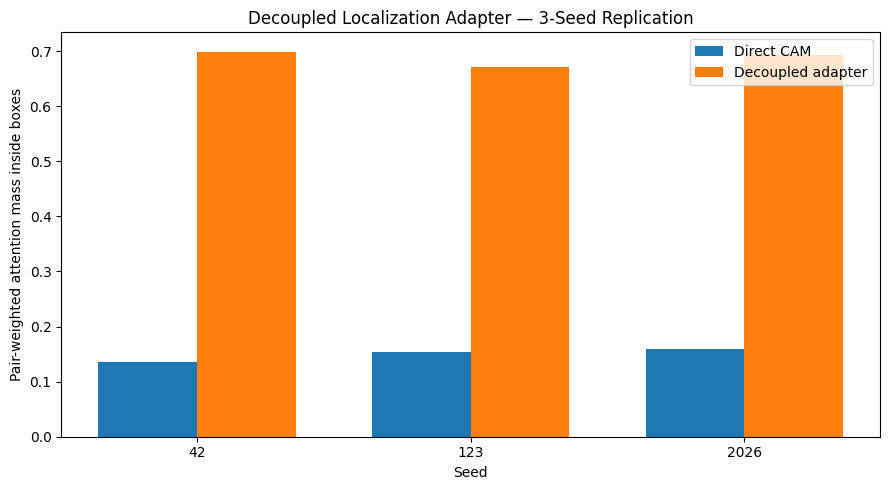

In [24]:
# ============================================================
# 26. Scientific plot: direct CAM vs adapter, all 3 seeds
# ============================================================
fig, ax = plt.subplots(
    figsize=(
        9,
        5,
    )
)

x = np.arange(
    len(
        three_seed
    )
)

width = 0.36

ax.bar(
    x
    - width
    / 2,
    three_seed[
        "baseline_direct_cam_attention_mass"
    ],
    width,
    label=
        "Direct CAM",
)

ax.bar(
    x
    + width
    / 2,
    three_seed[
        "adapter_attention_mass"
    ],
    width,
    label=
        "Decoupled adapter",
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    three_seed[
        "seed"
    ].astype(
        str
    )
)

ax.set_xlabel(
    "Seed"
)

ax.set_ylabel(
    "Pair-weighted attention mass inside boxes"
)

ax.set_title(
    "Decoupled Localization Adapter — 3-Seed Replication"
)

ax.legend()

plt.tight_layout()

plt.savefig(
    SUMMARY_DIR
    / "localization_three_seed_attention_mass.png",
    dpi=220,
    bbox_inches="tight",
)

plt.show()


In [25]:
# ============================================================
# 27. Final integrity gate
# ============================================================
new_configs = []

for seed in NEW_SEEDS:
    with open(
        OUTPUT_ROOT
        / RUN_EXPERIMENT_IDS[
            seed
        ]
        / "config.json",
        "r",
    ) as f:
        new_configs.append(
            json.load(
                f
            )
        )

checks = pd.DataFrame([
    {
        "check":
            "Frozen split SHA-256 verified",
        "passed":
            manifest_hash
            == EXPECTED_SPLIT_MANIFEST_SHA256,
    },
    {
        "check":
            "Train count = 5,408",
        "passed":
            len(
                train_df
            )
            == 5408,
    },
    {
        "check":
            "Validation count = 1,159",
        "passed":
            len(
                val_df
            )
            == 1159,
    },
    {
        "check":
            "M08 seed-42 reference verified",
        "passed":
            m08_config.get(
                "experiment_id"
            )
            == REFERENCE_LOCALIZATION_EXPERIMENT_ID,
    },
    {
        "check":
            "F01 seed-123 base checkpoint verified",
        "passed":
            BASE_CHECKPOINTS[
                123
            ][
                "checkpoint"
            ].get(
                "experiment_id"
            )
            == BASE_EXPERIMENT_IDS[
                123
            ],
    },
    {
        "check":
            "F01 seed-2026 base checkpoint verified",
        "passed":
            BASE_CHECKPOINTS[
                2026
            ][
                "checkpoint"
            ].get(
                "experiment_id"
            )
            == BASE_EXPERIMENT_IDS[
                2026
            ],
    },
    {
        "check":
            "Three localization seeds present",
        "passed":
            set(
                three_seed[
                    "seed"
                ].tolist()
            )
            == {
                42,
                123,
                2026,
            },
    },
    {
        "check":
            "All new base classifiers remain hash-identical",
        "passed":
            all(
                x[
                    "base_model_hash_unchanged"
                ]
                is True
                for x in new_configs
            ),
    },
    {
        "check":
            "All new base probability differences <= 1e-7",
        "passed":
            all(
                float(
                    x[
                        "max_disease_probability_difference"
                    ]
                )
                <= 1e-7
                for x in new_configs
            ),
    },
    {
        "check":
            "Exact adapter architecture frozen",
        "passed":
            all(
                x[
                    "adapter_architecture"
                ]
                == "Conv1x1(2048->256) + GroupNorm + ReLU + Conv1x1(256->37)"
                for x in new_configs
            ),
    },
    {
        "check":
            "Exact box loss weight 0.10",
        "passed":
            all(
                np.isclose(
                    x[
                        "box_loss_weight"
                    ],
                    0.10,
                )
                for x in new_configs
            ),
    },
    {
        "check":
            "Exact localization LR 1e-4",
        "passed":
            all(
                np.isclose(
                    x[
                        "localization_learning_rate"
                    ],
                    1e-4,
                )
                for x in new_configs
            ),
    },
    {
        "check":
            "All adapter attention-mass values finite",
        "passed":
            np.isfinite(
                three_seed[
                    "adapter_attention_mass"
                ].to_numpy(
                    dtype=float
                )
            ).all(),
    },
    {
        "check":
            "All adapter pointing values finite",
        "passed":
            np.isfinite(
                three_seed[
                    "adapter_pointing_accuracy"
                ].to_numpy(
                    dtype=float
                )
            ).all(),
    },
    {
        "check":
            "Calibration unused in new runs",
        "passed":
            all(
                x[
                    "calibration_used"
                ]
                is False
                for x in new_configs
            ),
    },
    {
        "check":
            "Official test unused in new runs",
        "passed":
            all(
                x[
                    "official_test_used"
                ]
                is False
                for x in new_configs
            ),
    },
    {
        "check":
            "No preprocessing failures",
        "passed":
            len(
                cache_failures
            )
            == 0,
    },
])

checks[
    "status"
] = checks[
    "passed"
].map({
    True:
        "PASS",
    False:
        "REVIEW",
})

checks.to_csv(
    SUMMARY_DIR
    / "final_integrity_status.csv",
    index=False,
)

display(
    checks
)

FINAL_STATUS = (
    "PASS"
    if checks[
        "passed"
    ].all()
    else "REVIEW"
)

print(
    "F02 LOCALIZATION 3-SEED FINAL STATUS:",
    FINAL_STATUS,
)

if (
    FINAL_STATUS
    != "PASS"
):
    raise RuntimeError(
        "Review integrity checks before freezing the final pipeline."
    )


,check,passed,status
0,Frozen split SHA-256 verified,True,PASS
1,"Train count = 5,408",True,PASS
2,"Validation count = 1,159",True,PASS
3,M08 seed-42 reference verified,True,PASS
4,F01 seed-123 base checkpoint verified,True,PASS
5,F01 seed-2026 base checkpoint verified,True,PASS
6,Three localization seeds present,True,PASS
7,All new base classifiers remain hash-identical,True,PASS
8,All new base probability differences <= 1e-7,True,PASS
9,Exact adapter architecture frozen,True,PASS


F02 LOCALIZATION 3-SEED FINAL STATUS: PASS


In [26]:
# ============================================================
# 28. Human-readable final summary
# ============================================================
def summary_metric(
    name,
):
    return (
        three_seed_summary.loc[
            three_seed_summary[
                "metric"
            ]
            == name
        ]
        .iloc[
            0
        ]
    )


mass = summary_metric(
    "adapter_attention_mass"
)

point = summary_metric(
    "adapter_pointing_accuracy"
)

finding_ap = summary_metric(
    "adapter_finding36_macro_AUPRC"
)

mass_gain = summary_metric(
    "attention_mass_gain"
)

point_gain = summary_metric(
    "pointing_gain"
)

readme = "\n".join([
    "F02 — Decoupled Localization Adapter Final 3-Seed Replication",
    "=" * 78,
    "",
    "SEEDS",
    "- 42: existing M08 reference",
    "- 123: exact M08 protocol on F01 seed-123 base classifier",
    "- 2026: exact M08 protocol on F01 seed-2026 base classifier",
    "",
    "FROZEN LOCALIZATION PROTOCOL",
    "- Adapter: Conv1x1(2048->256) + GroupNorm + ReLU + Conv1x1(256->37)",
    "- Base classifier frozen and feature maps detached",
    "- Local finding Focal loss gamma=2, weight=1.0",
    "- Box attention-mass loss weight=0.10",
    "- Adapter LR=1e-4, AdamW, weight decay=1e-4",
    "- Checkpoint selected by pair-weighted validation attention mass",
    "",
    "3-SEED LOCALIZATION RESULTS",
    (
        "- Attention mass inside boxes: "
        f"{mass['mean']:.6f} ± {mass['std_sample']:.6f}"
    ),
    (
        "- Pointing-game accuracy: "
        f"{point['mean']:.6f} ± {point['std_sample']:.6f}"
    ),
    (
        "- Adapter finding Macro-AUPRC: "
        f"{finding_ap['mean']:.6f} ± {finding_ap['std_sample']:.6f}"
    ),
    (
        "- Attention-mass gain vs direct CAM: "
        f"{mass_gain['mean']:.6f} ± {mass_gain['std_sample']:.6f}"
    ),
    (
        "- Pointing-game gain vs direct CAM: "
        f"{point_gain['mean']:.6f} ± {point_gain['std_sample']:.6f}"
    ),
    "",
    "INTEGRITY",
    "- All new base classifiers remained exactly frozen",
    "- Calibration used: NO",
    "- Official test used: NO",
    f"- Frozen split SHA-256: {manifest_hash}",
    "",
    "NEXT",
    "- Freeze the final development pipeline.",
    "- Then prepare the one-time official-test evaluation notebook.",
])

print(
    readme
)

with open(
    SUMMARY_DIR
    / "README_RESULTS.txt",
    "w",
) as f:
    f.write(
        readme
    )


F02 — Decoupled Localization Adapter Final 3-Seed Replication

SEEDS
- 42: existing M08 reference
- 123: exact M08 protocol on F01 seed-123 base classifier
- 2026: exact M08 protocol on F01 seed-2026 base classifier

FROZEN LOCALIZATION PROTOCOL
- Adapter: Conv1x1(2048->256) + GroupNorm + ReLU + Conv1x1(256->37)
- Base classifier frozen and feature maps detached
- Local finding Focal loss gamma=2, weight=1.0
- Box attention-mass loss weight=0.10
- Adapter LR=1e-4, AdamW, weight decay=1e-4
- Checkpoint selected by pair-weighted validation attention mass

3-SEED LOCALIZATION RESULTS
- Attention mass inside boxes: 0.687550 ± 0.014767
- Pointing-game accuracy: 0.735788 ± 0.009560
- Adapter finding Macro-AUPRC: 0.081423 ± 0.014950
- Attention-mass gain vs direct CAM: 0.537690 ± 0.023974
- Pointing-game gain vs direct CAM: 0.505814 ± 0.006988

INTEGRITY
- All new base classifiers remained exactly frozen
- Calibration used: NO
- Official test used: NO
- Frozen split SHA-256: 3d2f8de854c9f6138

In [27]:
# ============================================================
# 29. Package complete F02 output
# ============================================================
ZIP_FILE = Path(
    "/kaggle/working/"
    "F02_LocalizationAdapter_3Seed_Replication_All_Outputs.zip"
)

if (
    ZIP_FILE.exists()
):
    ZIP_FILE.unlink()

source_files = sorted(
    p
    for p in OUTPUT_ROOT.rglob(
        "*"
    )
    if p.is_file()
)

if (
    not source_files
):
    raise RuntimeError(
        "No F02 output files found."
    )

blocked_extensions = {
    ".dcm",
    ".dicom",
    ".npy",
    ".npz",
}

for p in source_files:
    if (
        p.suffix.lower()
        in blocked_extensions
    ):
        raise RuntimeError(
            "STOP: restricted/cache file detected in output folder: "
            + str(
                p
            )
        )

with zipfile.ZipFile(
    ZIP_FILE,
    mode="w",
    compression=
        zipfile.ZIP_DEFLATED,
    compresslevel=6,
) as zf:
    for p in source_files:
        zf.write(
            p,
            arcname=str(
                Path(
                    CONTROLLER_ID
                )
                / p.relative_to(
                    OUTPUT_ROOT
                )
            ),
        )

with zipfile.ZipFile(
    ZIP_FILE,
    "r",
) as zf:
    corrupt = (
        zf.testzip()
    )
    names = (
        zf.namelist()
    )

if (
    corrupt
    is not None
):
    raise RuntimeError(
        "ZIP integrity failure: "
        + str(
            corrupt
        )
    )

required_outputs = [
    "F02_LocalizationAdapter_Seed123/best_localization_adapter.pth",
    "F02_LocalizationAdapter_Seed2026/best_localization_adapter.pth",
    "summary/localization_three_seed_results.csv",
    "summary/localization_three_seed_mean_sd.csv",
    "summary/per_finding_localization_three_seed_mean_sd.csv",
    "summary/final_integrity_status.csv",
    "summary/README_RESULTS.txt",
]

missing_outputs = [
    x
    for x in required_outputs
    if (
        not any(
            name.endswith(
                x
            )
            for name in names
        )
    )
]

if (
    missing_outputs
):
    raise RuntimeError(
        "ZIP missing required outputs: "
        + str(
            missing_outputs
        )
    )

print(
    "✅ F02 COMPLETE OUTPUT ZIP CREATED"
)
print(
    "File:",
    ZIP_FILE,
)
print(
    "ZIP size:",
    f"{ZIP_FILE.stat().st_size/(1024**2):.2f} MB",
)
print(
    "ZIP integrity: PASS"
)
print(
    "DICOM/cache files included: NO"
)
print(
    "Official test used: NO"
)


✅ F02 COMPLETE OUTPUT ZIP CREATED
File: /kaggle/working/F02_LocalizationAdapter_3Seed_Replication_All_Outputs.zip
ZIP size: 4.29 MB
ZIP integrity: PASS
DICOM/cache files included: NO
Official test used: NO


## What to send back

After the run finishes, send:

`F02_LocalizationAdapter_3Seed_Replication_All_Outputs.zip`

I will verify:

- localization attention mass for seeds 42 / 123 / 2026;
- pointing-game stability;
- adapter finding-head stability;
- direct-CAM → adapter localization gains;
- per-finding variability;
- exact preservation of each seed-specific disease classifier;
- all integrity checks.

If 13B passes, we will freeze the development pipeline and prepare the **one-time official test evaluation**.
